# Analysis of Persuasion Characteristics in Argumentative Content in Discussion Groups
Text Mining Project by **Odeliah Movadat** and **Dikla Vilge**

# １. Introduction

## 1.1. The CMV Forum on Reddit and the "Delta" Concept

[Change My View](https://www.reddit.com/r/changemyview/) (CMV) is a popular subreddit on Reddit where users engage in structured debates with the goal of persuading others to reconsider their viewpoints. Unlike typical internet arguments, CMV encourages respectful discourse, requiring users to provide well-reasoned arguments and evidence. A core feature of CMV is the "delta" system: if a user successfully changes another participant’s mind, the persuaded user awards them a "delta" symbol (∆). This delta serves as an indicator of a convincing argument, making CMV a unique platform for studying persuasion in online discussions. The structured format of the forum, combined with the delta-based feedback, provides a valuable dataset for analyzing what makes an argument compelling.

## 1.2. Goals of the Work

The main objective of this project is to explore the properties that differentiate persuasive arguments from non-persuasive ones. Specifically, we aim to:

* Identify textual properties that contribute to persuasion.

* Analyze the differences between convincing and non-convincing arguments.

* Develop a machine learning model capable of predicting whether an argument is convincing based on its linguistic and structural features.
By achieving these goals, we aim to gain deeper insights into the mechanics of persuasion and contribute to the broader field of computational argumentation analysis.

## 1.3. Motivation

Previous research has leveraged CMV discussions to study persuasion, but earlier studies were often limited by the analytical methods available at the time. With recent advancements in natural language processing (NLP) and machine learning, we now have the tools to extract more nuanced insights from text data. By applying modern text mining techniques, such as transformer-based language models and sophisticated feature engineering methods, we can potentially improve upon previous results and enhance our understanding of what makes an argument compelling. This work has practical applications in areas such as automated debate analysis, content moderation, and persuasive writing assistance.

## 1.4. Process Overview

The research follows a structured methodology to analyze persuasive arguments effectively:

1. **Data Collection & Preparation:** We compile a dataset from CMV discussions, ensuring that each row includes the argument (comment), the context in which it was made, and whether it was awarded a delta (indicating it was convincing).

2. **Feature Engineering:** We identify and extract key textual properties that may influence persuasion, such as sentiment, readability, rhetorical devices, and linguistic complexity.

3. **Model Development & Evaluation:** The extracted features are fed into a machine learning model, which is trained to predict whether an argument will receive a delta. The model's performance is then evaluated using standard classification metrics to determine its effectiveness.

By following this approach, we aim to contribute valuable insights into the nature of persuasive language and refine techniques for automatic persuasion detection.



# ２. Collecting Raw Data

We have 3 sources for the data:

1. Data from a previous study: https://github.com/jpriniski/CMV/tree/master/Study2.
How was it generated? They downloaded the data from redit and stored it in Study2/data directory. Then they executed a script to process the data and srored it in Study2/data/coded. The coded data is what we need.

2. In addition we need to take the data provided to us by Chaya Liebeskind and run the same processing on it.

3. The third data set is data we dowloaded ourselves from reddit. It, too, needs to be processed the same way.

In [ ]:
import pandas as pd
import json


from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2.1 Study2 Data

In [ ]:
study2_path = "/content/drive/MyDrive/תואר שני/שנה ב סמסטר א/כריית טקסטים/פרויקט סיום/data/Study2/20180815182030_posts.json"

In [ ]:
with open(study2_path, 'r') as f:
    data = json.load(f)

data1_df = pd.DataFrame(data)
data1_df.head(5)

,approved_at_utc,selftext,user_reports,saved,mod_reason_title,gilded,clicked,title,link_flair_richtext,subreddit_name_prefixed,...,media,is_video,_fetched,_info_params,comment_limit,comment_sort,_flair,_mod,_comments,topic
0,None,It's no secret - owners of sports teams are us...,[],False,None,0,False,CMV: taxpayers and the general public should n...,[],r/changemyview,...,None,False,False,{},2048,best,None,None,"[{'_mod': None, 'subreddit_id': 't5_2w2s8', 'a...","{'gender': 0, 'hot_topics': 0, 'lgbt': 0, 'mor..."
1,None,The main focus of my stance is people who have...,[],False,None,0,False,CMV: People who have been wrongfully imprisone...,[],r/changemyview,...,None,False,False,{},2048,best,None,None,"[{'_mod': None, 'subreddit_id': 't5_2w2s8', 'a...","{'gender': 1, 'hot_topics': 1, 'lgbt': 0, 'mor..."
2,None,Supreme executive power derives from a mandate...,[],False,None,2,False,CMV:Strange women lying in ponds distributing ...,[],r/changemyview,...,None,False,False,{},2048,best,None,None,"[{'_mod': None, 'subreddit_id': 't5_2w2s8', 'a...","{'gender': 1, 'hot_topics': 0, 'lgbt': 0, 'mor..."
3,None,Let me start by explaining what I mean when I ...,[],False,None,0,False,"CMV: Instead of teaching youth to ""not judge"" ...",[],r/changemyview,...,None,False,False,{},2048,best,None,None,"[{'_mod': None, 'subreddit_id': 't5_2w2s8', 'a...","{'gender': 1, 'hot_topics': 0, 'lgbt': 0, 'mor..."
4,None,Let me be clear. I know this cannot be imposed...,[],False,None,0,False,"CMV: Just like sex education, religion should ...",[],r/changemyview,...,None,False,False,{},2048,best,None,None,"[{'_mod': None, 'subreddit_id': 't5_2w2s8', 'a...","{'gender': 0, 'hot_topics': 0, 'lgbt': 0, 'mor..."


The identifer of each thread is stored in the id column:

In [ ]:
data1_df['id']

,id
0,7ej2uh
1,8jzpca
2,4k83qf
3,7usy79
4,647u7d
5,6wcd0a
6,83lq6t
7,8jr260
8,6yjmgl
9,60u6bk


## 2.2 The Data from Chaya

Now we need to prepare redit_data. first we need to make a single file out of all the json files

In [ ]:
redit_data_dir_path = '/content/drive/MyDrive/תואר שני/שנה ב סמסטר א/כריית טקסטים/פרויקט סיום/redit_data'

In [ ]:
import os
import json

combined_data = []
for filename in os.listdir(redit_data_dir_path):
  if filename.endswith(".json"):
    filepath = os.path.join(redit_data_dir_path, filename)
    with open(filepath, 'r') as f:
      try:
        data = json.load(f)
        if isinstance(data, list):
          combined_data.extend(data)
        else:
          combined_data.append(data)
      except json.JSONDecodeError as e:
        print(f"Error decoding JSON in file {filename}: {e}")

output_filepath = os.path.join(redit_data_dir_path, "combined.json")
with open(output_filepath, 'w') as f:
  json.dump(combined_data, f, indent=2)

We cloned the git repo into the local development environment, and put the combined json into the repo. We executed the discussion_analysis script over it, to process the data and get a similar structure like the data of study 2. The new data contains the delta column.

We will load the resulting data into a dataframe.


In [ ]:
new_data_coded_path = '/content/drive/MyDrive/תואר שני/שנה ב סמסטר א/כריית טקסטים/פרויקט סיום/data/combined.json'
with open(new_data_coded_path, 'r') as f:
    data = json.load(f)

data2_df = pd.DataFrame(data)
data2_df.head(5)

,approved_at_utc,selftext,user_reports,saved,mod_reason_title,gilded,clicked,title,link_flair_richtext,subreddit_name_prefixed,...,media,is_video,_fetched,_info_params,comment_limit,comment_sort,_flair,_mod,_comments,topic
0,None,Mike Bloomberg recently dropped out of the 202...,[],False,None,1,False,CMV: Mike Bloomberg's campaign is proof that t...,[],r/changemyview,...,None,False,False,None,2048,confidence,None,None,"[{'_mod': None, 'subreddit_id': 't5_2w2s8', 'a...","{'gender': {'match': True, 'terms': [['he']]},..."
1,None,Kanye West is a shill for president Trump and ...,[],False,None,4,False,CMV: Kanye West is a shill for president Trump...,[],r/changemyview,...,None,False,False,None,2048,confidence,None,None,"[{'_mod': None, 'subreddit_id': 't5_2w2s8', 'a...","{'gender': {'match': True, 'terms': [['he'], [..."
2,None,I used to think I was against a national healt...,[],False,None,0,False,CMV: Most Americans who oppose a national heal...,[],r/changemyview,...,None,False,False,None,2048,confidence,None,None,"[{'_mod': None, 'subreddit_id': 't5_2w2s8', 'a...","{'gender': {'match': True, 'terms': [['she'], ..."
3,None,I write this because I am tired of the wild go...,[],False,None,4,False,CMV: Donald Trump has not made a single lastin...,[],r/changemyview,...,None,False,False,None,2048,confidence,None,None,"[{'_mod': None, 'subreddit_id': 't5_2w2s8', 'a...","{'gender': {'match': True, 'terms': [['he']]},..."
4,None,"From what I know, Christ was essentially a rad...",[],False,None,1,False,CMV: being a conservative is the least Christ-...,[],r/changemyview,...,None,False,False,None,2048,confidence,None,None,"[{'_mod': None, 'subreddit_id': 't5_2w2s8', 'a...","{'gender': {'match': True, 'terms': [['boy'], ..."


## 2.3 The Downloaded Data

We downloaded from Redit the top 500 threads using collect_posts script. We executed the discussion_analysis script on the downloaded file, zipped the result and uploaded to drive. Now, we will read the file from drive, unzip it and load it into a third dataframe.

In [ ]:
our_downloaded_data_path = '/content/drive/MyDrive/תואר שני/שנה ב סמסטר א/כריית טקסטים/פרויקט סיום/20250210005631_posts.zip'


In [ ]:
# prompt: the file our_downloaded_data_path is a zip file. Extract the zip, and read the resulting json  into a dataframe

import zipfile
import pandas as pd
import json

# Extract the zip file
with zipfile.ZipFile(our_downloaded_data_path, 'r') as zip_ref:
    zip_ref.extractall("extracted_data")

# Find the JSON file within the extracted directory
import os
for filename in os.listdir("extracted_data"):
    if filename.endswith(".json"):
        json_filepath = os.path.join("extracted_data", filename)
        break

# Read the JSON file into a DataFrame
try:
    with open(json_filepath, 'r') as f:
        data = json.load(f)
    data3_df = pd.DataFrame(data)
    print(data3_df.head()) # Print the first few rows of the DataFrame
except FileNotFoundError:
    print(f"Error: JSON file not found in the extracted directory.")
except json.JSONDecodeError:
    print(f"Error: Invalid JSON format in the file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

## 2.4 Combined DataSet

Since the data was collected in different times, it may contain duplicate ids and the content may differ. We want to keep the newer version of any duplicate. The order of the download from old to new is: study2, reddit data, our downloaded data.

So we always keep the copy in the newer dataset.

First, remove from data1 all ids that exist in data2:

In [ ]:
# Original count of examples in study2:
print(len(data1_df))

29


In [ ]:
ids_to_remove = set(data1_df['id']).intersection(set(data2_df['id']))
data1_df = data1_df[~data1_df['id'].isin(ids_to_remove)]


In [ ]:
# How many rows are left in study2_df?

print(len(data1_df))


27


Now we combine data1 and data2:

In [ ]:
import pandas as pd
combined12_df = pd.concat([data1_df, data2_df], ignore_index=True)

Now, remove from the combined data of data1 and data2, all ids that exist in data3:

In [ ]:
print(len(combined12_df))

119


In [ ]:
ids_to_remove = set(combined12_df['id']).intersection(set(data3_df['id']))
combined12_df = combined12_df[~combined12_df['id'].isin(ids_to_remove)]

In [ ]:
print(len(combined12_df))

8


In [ ]:
df = pd.concat([combined12_df, data3_df], ignore_index=True)

In [ ]:
print(len(df))

433


This is our final dataframe, without duplicates, and with the newest version of each thread.

# ３. Understanding Raw Data

In [ ]:
df.columns

Index(['approved_at_utc', 'selftext', 'user_reports', 'saved',
       'mod_reason_title', 'gilded', 'clicked', 'title', 'link_flair_richtext',
       'subreddit_name_prefixed', 'hidden', 'pwls', 'link_flair_css_class',
       'downs', 'parent_whitelist_status', 'hide_score', 'name', 'quarantine',
       'link_flair_text_color', 'author_flair_background_color',
       'subreddit_type', 'ups', 'domain', 'media_embed',
       'author_flair_template_id', 'is_original_content', 'secure_media',
       'is_reddit_media_domain', 'is_meta', 'category', 'secure_media_embed',
       'link_flair_text', 'can_mod_post', 'score', 'approved_by', 'thumbnail',
       'edited', 'author_flair_css_class', 'author_flair_richtext',
       'content_categories', 'is_self', 'mod_note', 'created',
       'link_flair_type', 'wls', 'banned_by', 'author_flair_type',
       'contest_mode', 'selftext_html', 'likes', 'suggested_sort',
       'banned_at_utc', 'view_count', 'archived', 'no_follow',
       'is_crossposta

Let's try to "feel" what's inside some of the columns:

In [ ]:
df.iloc[0]['_comments'][0]

{'_mod': None,
 'subreddit_id': 't5_2w2s8',
 'approved_at_utc': None,
 'ups': 1,
 'mod_reason_by': None,
 'banned_by': None,
 'removal_reason': None,
 'link_id': 't3_7usy79',
 'author_flair_type': 'text',
 'author_flair_template_id': None,
 'likes': None,
 'no_follow': False,
 'user_reports': [],
 'saved': False,
 'id': 'dtn63tp',
 'banned_at_utc': None,
 'mod_reason_title': None,
 'gilded': 0,
 'archived': True,
 'report_reasons': None,
 'author': 'DeltaBot',
 'can_mod_post': False,
 'send_replies': True,
 'parent_id': 't3_7usy79',
 'score': 1,
 'approved_by': None,
 'downs': 0,
 'body': "/u/justmikewilldo (OP) has awarded 3 deltas in this post.\n\nAll comments that earned deltas (from OP or other users) are listed [**here**](/r/DeltaLog/comments/7uu885), in /r/DeltaLog.\n\nPlease note that a change of view [doesn't necessarily mean a reversal](https://www.reddit.com/r/changemyview/wiki/index#wiki_what_is_a_.27view.27.3F), or that the conversation has ended.\n\n^[Delta\xa0System\xa0Ex

In [ ]:
df.iloc[0]['_comments'][0]['Delta']

{'count': 0, 'from': {}}

In [ ]:
df.iloc[0]['_comments'][0]['body']


"/u/justmikewilldo (OP) has awarded 3 deltas in this post.\n\nAll comments that earned deltas (from OP or other users) are listed [**here**](/r/DeltaLog/comments/7uu885), in /r/DeltaLog.\n\nPlease note that a change of view [doesn't necessarily mean a reversal](https://www.reddit.com/r/changemyview/wiki/index#wiki_what_is_a_.27view.27.3F), or that the conversation has ended.\n\n^[Delta\xa0System\xa0Explained](https://www.reddit.com/r/changemyview/wiki/deltasystem) ^| ^[Deltaboards](https://www.reddit.com/r/changemyview/wiki/deltaboards)"

In [ ]:
df.iloc[0]['_comments'][0]['evidence_use']

{'data': 0,
 'economics': 0,
 'evidence': 0,
 'numbers': 0,
 'stats': 1,
 'values': 0}

In [ ]:
thread = df.iloc[0]['_comments']
comments = {com['id']: com for com in thread}
comments

In [ ]:
# 1 comment example:
comment_id = 'dtsmms8'  # selected randomly manually from the list above
parent_id = comments[comment_id]['parent_id']
parent_id

't1_dtoimcb'

In [ ]:
for comment in comments.values():
  comment['parent_id_edited'] = comment['parent_id'].split('_')[1]

In [ ]:
print("The parent comment:")
print(comments[parent_id.split('_')[1]]['body'])
print()
print("The original comment:")
print(comments[comment_id]['body'])

The parent comment:
That is your opinion.


The original comment:
I guess? In my experience people who are *truly* hopeless, not just looking for internet points, are typically homeless or suicidal, or addicts. I don't know of anyone who is a person who has no hopes who's doing so well for themselves. 


In [ ]:
df.iloc[0]['id']

'7usy79'

In [ ]:
df.iloc[0]['title']

'CMV: Instead of teaching youth to "not judge" we should be teaching them *how* to judge with kindness, mercy, logic, and fairness.'

In [ ]:
print(df.iloc[0]['selftext'].replace('\n', '\n'))

print("\n--- Authored by: " + df.iloc[0]['author'])


Let me start by explaining what I mean when I say judge in this context. 

I am a father of a 5 year old girl and as anyone who's spent a lot of time with babies and young children, I want to help guide her through life and give her the tools to interpret the world around her. 

When we see a child behaving very poorly in public there are times when I choose to speak with her about what's happening. At the onset of this moment, when we are going to voice our thoughts about the behavior of others, whether it's my daughter and I, you by yourself in your head, or anyone in really any circumstance, we are entering a judgmental space by it's literal definition. 

Any way to frame, or speak about some else's actions requires judgments to be made. Our society has made the word 'judgmental' have strong negative connotations, and I believe people are uncomfortable with using others as teaching opportunities for fear of being "judgmental" 

Here's an example of what I'm talking about. Daughter a

In [ ]:
# print a few examples for a comment that is a child of the original body
counter = 0
for comment in comments.values():
  if comment['parent_id_edited'] == df.iloc[0]['id']:
    print(comment['body'])
    print("\n--- Authored by: " + comment['author'])
    print("-----------------------")
    counter += 1
    if counter == 3:
      break

/u/justmikewilldo (OP) has awarded 3 deltas in this post.

All comments that earned deltas (from OP or other users) are listed [**here**](/r/DeltaLog/comments/7uu885), in /r/DeltaLog.

Please note that a change of view [doesn't necessarily mean a reversal](https://www.reddit.com/r/changemyview/wiki/index#wiki_what_is_a_.27view.27.3F), or that the conversation has ended.

^[Delta System Explained](https://www.reddit.com/r/changemyview/wiki/deltasystem) ^| ^[Deltaboards](https://www.reddit.com/r/changemyview/wiki/deltaboards)

--- Authored by: DeltaBot
-----------------------
I am not trying to change your view because it is one the I espouse myself - having worked in Childcare for quite a few years I can attest to how this view not only helps children but creates a relationship full of trust, respect, and even love. In my experience children really pick up on the respect part and can more genuinely reciprocate and manage their emotions better when it is their own behaviors being scrutin

# ４. Creating the Comments DataSet

The raw data contains a row for every thread. We want to find the convincing comments and create for each of them a row that contains:
* The original post
* The convincing comment
* The context: all the previous comments in the thread that were authored by the same same author as the convincing comment
* The class = is_convincing = true
* The convincing comment id (for debugging purposes)

We will throw away any additional comments that come AFTER the convincing comment in the thead.

Then, for every "leaf" in the tree of comments, we will create an appropriate row with the same structure, and set is_convincing = false. Unless the leaf is a parent of a (removed) convincing comment.

**Note:** we chose to define the context of the comment as only the comments by the same author. We could use all the comments in the thread instead. There are pros and cons for each approach.

If we only use the comments by the same author, we may lose other comments by different authors that represent the same "side" of the argument as the author of the convincing comment, and these additional commnets may affect the overall persuasion.

However, using only the same author guarentees that the "context" will have the same writing style, sentiment and opinion as the convincing comment. The style and sentiment are important for the features that we will later create from the data.

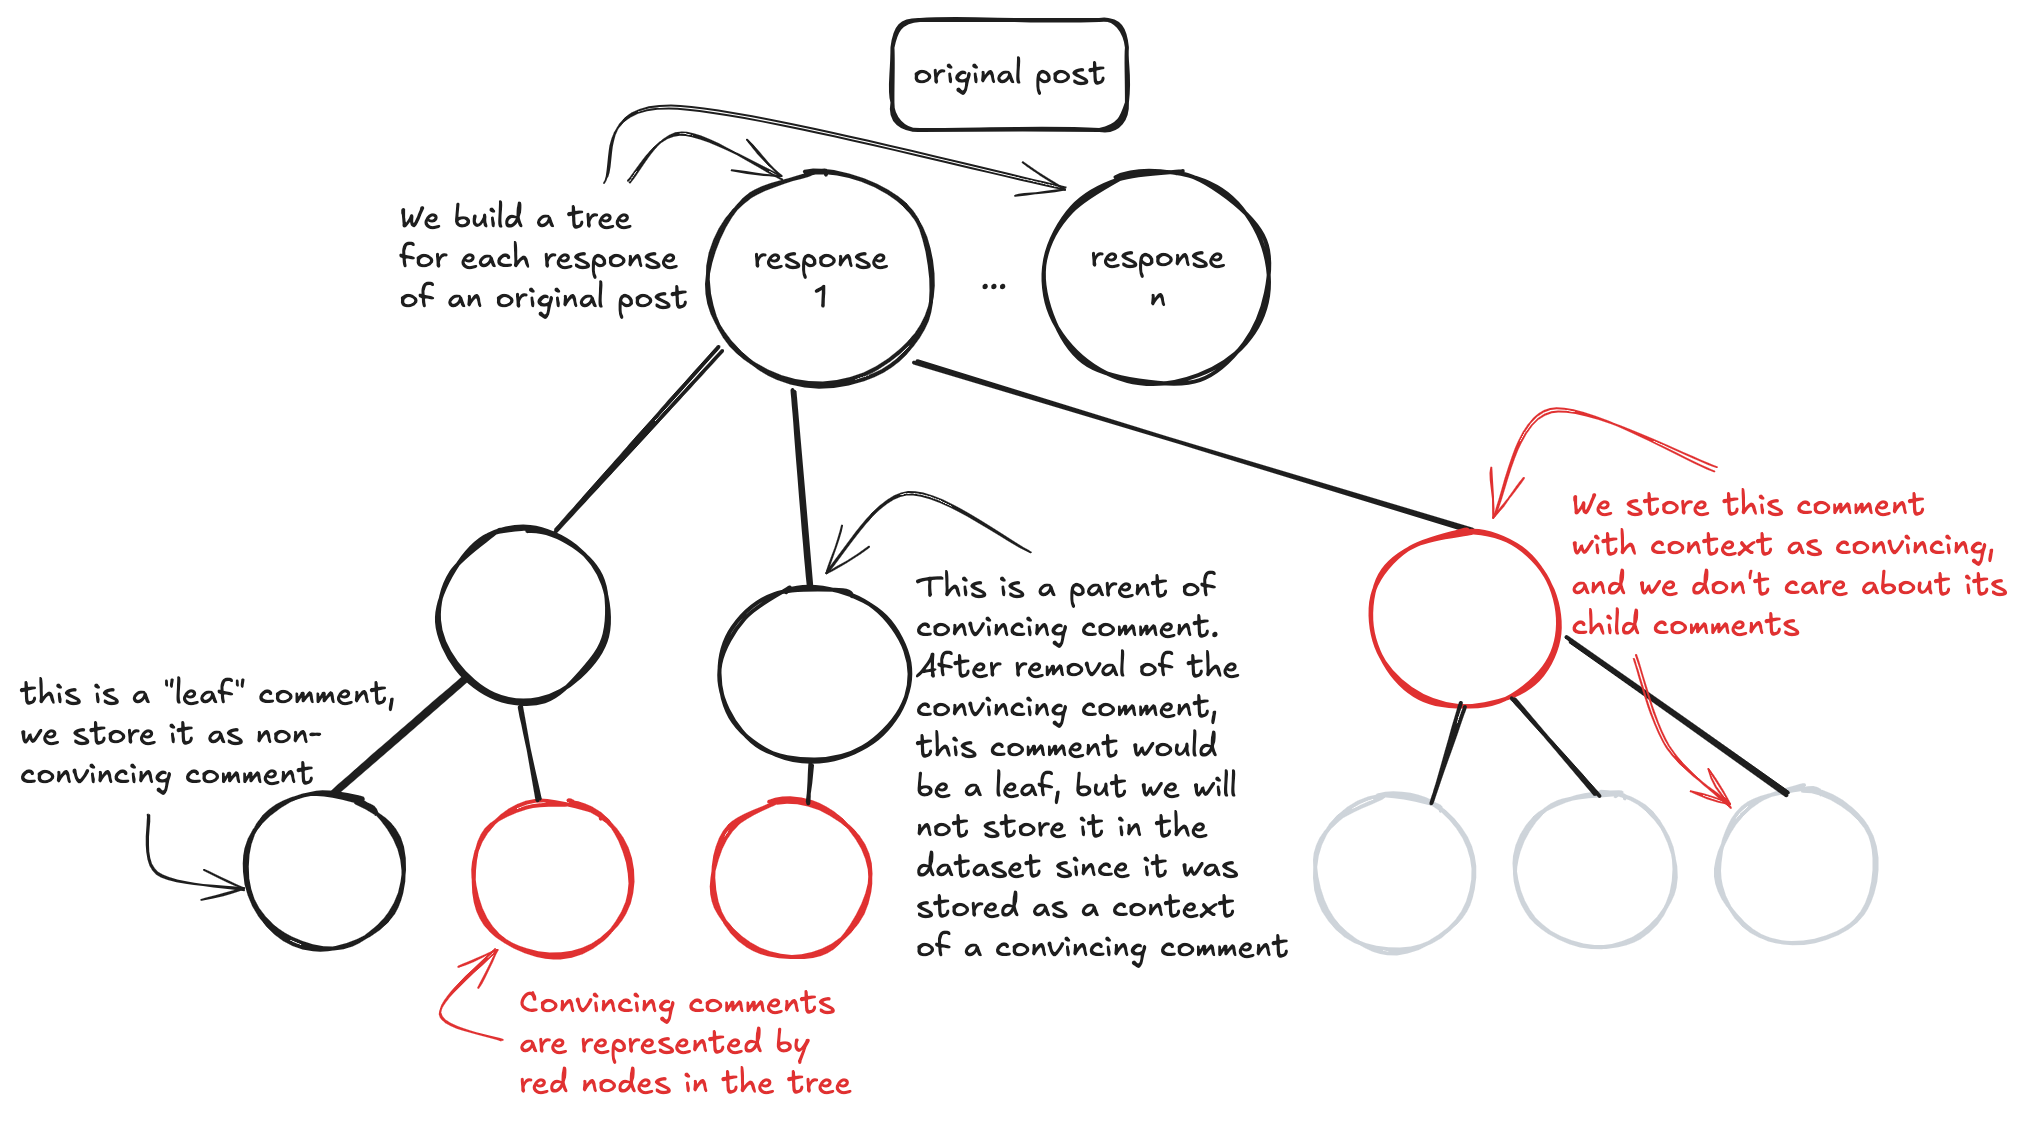

First, we will create the code to build the tree. As an example, we will work on an arbitrary row in the dataframe. Later we will use this code on all the rows in the df.

In [ ]:

def add_children(comment, all_comments):
    child_comments = [com for com in all_comments if com['parent_id_edited'] == comment['id']]
    if not child_comments:
        return

    for child_comment in child_comments:
      child_comment['children'] = []
      comment['children'].append(child_comment)
      add_children(child_comment, all_comments)

def build_comment_tree(comments, original_post_id):
    comment_map = {comment['id']: comment for comment in comments}
    tree = []

    for comment in comments:
        if comment['parent_id_edited'] == original_post_id:
            comment['children'] = []
            tree.append(comment)

    for comment in tree:
        add_children(comment, comments)

    return tree

# Example usage with the comments from the first thread in the dataframe
thread = df.iloc[0]['_comments']
for comment in thread:
    comment['parent_id_edited'] = comment['parent_id'].split('_')[1]

comment_tree = build_comment_tree(thread, df.iloc[0]['id'])
print(json.dumps(comment_tree, indent=2))


The next step would be to travel the entire tree and find the convincing comments. For these comments we will:
1. add them to a data frame with the original post and the previous comments of the same author in the thread
2. mark their parent as parent_of_convincing = true
3. drop the comment from the tree

In [ ]:
import pandas as pd
import copy

separator_token = "[SEP]"

def add_new_row(current_comment, previous_comments, original_post, is_convincing, df):
  if not current_comment.get('author') or not current_comment.get('body'): # a deleted comment, we can't add it
    return
  convincing_comment_context = ""
  if previous_comments.get(current_comment['author']):
    convincing_comment_context = f"\n{separator_token}\n".join(previous_comments[current_comment['author']])

  new_row = {'original_post': original_post, 'thread_text': convincing_comment_context, 'final_comment': current_comment['body'], 'is_convincing': is_convincing, 'final_comment_id': current_comment['id']}
  df.loc[len(df)] = new_row

def add_convincing_comments(comment_tree, convincing_comments_df, original_post, parent_comment=None, comments_in_thread = {}):
    for comment in comment_tree:
        if comment.get('Delta', {}).get('count', 0) > 0:
            add_new_row(comment, comments_in_thread, original_post, 1, convincing_comments_df)

            if parent_comment:
                parent_comment['parent_of_convincing'] = True

            comment_tree.remove(comment)

        # If the comment was convincing, we ignore its children. Otherwise we continue recursively with the children:
        elif 'children' in comment and comment['children']:
            if not comment.get('author') or not comment.get('body'):
              continue
            if not comments_in_thread.get(comment['author']):
              comments_in_thread[comment['author']] = []
            comments_in_thread[comment['author']].append(comment['body'])

            add_convincing_comments(comment['children'], convincing_comments_df, original_post, comment, comments_in_thread)
            comments_in_thread[comment['author']].pop()

# Example usage:
row = df.iloc[4]

thread_comments = row['_comments']
for comment in thread_comments:
    comment['parent_id_edited'] = comment['parent_id'].split('_')[1]

comment_tree = build_comment_tree(thread_comments, row['id'])

convincing_comments_df = pd.DataFrame(columns=['original_post', 'thread_text', 'final_comment', 'is_convincing', 'final_comment_id']) # Initialize an empty DataFrame
add_convincing_comments(comment_tree, convincing_comments_df, row['selftext'])
# print(convincing_comments_df['final_comment_id'])

convincing_comments_df

In [ ]:
def add_non_convincing_comments(comment_tree, convincing_comments_df, original_post, comments_in_thread = {}):
    for comment in comment_tree:
      if not comment.get('author') or not comment.get('body'):
        continue

      if not comment.get('children'): # this is a leaf
        if not comment.get('parent_of_convincing') and not comment['author'] == 'DeltaBot':
          add_new_row(comment, comments_in_thread, original_post, 0, convincing_comments_df)
          # else ignore this leaf
        return


      # else, the comment has children

      if not comments_in_thread.get(comment['author']):
        comments_in_thread[comment['author']] = []
      comments_in_thread[comment['author']].append(comment['body'])

      add_non_convincing_comments(comment['children'], convincing_comments_df, original_post, comments_in_thread)
      comments_in_thread[comment['author']].pop()

# example usage, with the same tree that we craeted before and removed the convincing comments from:
add_non_convincing_comments(comment_tree, convincing_comments_df, row['selftext'])
convincing_comments_df

,original_post,thread_text,final_comment,is_convincing,final_comment_id
0,"Please do not downvote me, even if you resent ...",,>Since I earned significant income in my attem...,1,e3lvd1e
1,"Please do not downvote me, even if you resent ...",,As a non religious individual I often consider...,1,e3lrxbr
2,"Please do not downvote me, even if you resent ...",Are humans not part of the universe? This very...,What I mean is - the universe can only be indi...,1,e3lz4vz
3,"Please do not downvote me, even if you resent ...",,"While I'm not religious, I'm sympathetic to re...",1,e3lurq9
4,"Please do not downvote me, even if you resent ...",,If you really want to challenge your views loo...,1,e3lvw0j
...,...,...,...,...,...
83,Let me start by explaining what I mean when I ...,I think that there's an important distinction ...,"Yes, exactly. Thank you for adding the resear...",0,dtnc340
84,Let me start by explaining what I mean when I ...,There's a difference between judgement and dis...,"Yeah, the reason you have to use a hypothetica...",0,dtna38k
85,Let me start by explaining what I mean when I ...,,"In my opinion the phrase ""don't judge"" isn't a...",0,dtnnvbf
86,Let me start by explaining what I mean when I ...,I used to tell my kids never to judge a person...,My daughter is 15. She does not tolerate bully...,0,dtn8xi8


In the above case, there were no leaves left.

Now we can execute this logic on all the rows, and create the final dataframe.

The final change here, is to add the post title to the original post field:

In [ ]:
comments_df = pd.DataFrame(columns=['original_post', 'thread_text', 'final_comment', 'is_convincing', 'final_comment_id']) # Initialize an empty DataFrame


# Loop through all rows in the DataFrame 'df'
for index, row in df.iterrows():
    thread_comments = row['_comments']
    for comment in thread_comments:
        comment['parent_id_edited'] = comment['parent_id'].split('_')[1]

    comment_tree = build_comment_tree(thread_comments, row['id'])

    original_post = str(row['title']) + "\n" + str(row['selftext'])

    add_convincing_comments(comment_tree, comments_df, original_post)
    add_non_convincing_comments(comment_tree, comments_df, original_post)

comments_df.head(10)


,original_post,thread_text,final_comment,is_convincing,final_comment_id
0,"CMV: Instead of teaching youth to ""not judge"" ...",,I agree with mercy. But sometimes mercy can ro...,0,dtni266
1,"CMV: Instead of teaching youth to ""not judge"" ...",,I’m also an early childhood educator and came ...,0,dtnii0t
2,"CMV: Instead of teaching youth to ""not judge"" ...",I am not trying to change your view because it...,I would try to use the most Neutral vocabulary...,0,dtr7sbi
3,"CMV: Instead of teaching youth to ""not judge"" ...",What do you mean by having your self-esteem wr...,"And thank you, surprisingly kind and reasonabl...",0,dtvacj0
4,"CMV: Instead of teaching youth to ""not judge"" ...",The human brain is explicitly evolved to judge...,"Agreed... this is how we live, how our species...",0,dtrsop3
5,"CMV: Instead of teaching youth to ""not judge"" ...",,I think that their point is probably that you ...,0,dtndrgc
6,"CMV: Instead of teaching youth to ""not judge"" ...",,Honestly the phrase “don’t judge” is really me...,0,dtnvjtm
7,"CMV: Instead of teaching youth to ""not judge"" ...",I agree that judging positively is better than...,Disclaimer that I'm neither a parent nor do I ...,0,dtn71uk
8,"CMV: Instead of teaching youth to ""not judge"" ...","I have a son that’s 6 going on 7, and my wife ...",Yeah the principles we use are vague on purpos...,0,dtnbt4r
9,"CMV: Instead of teaching youth to ""not judge"" ...",There's a concept in psychology called [Fundam...,We have the capacity to make judgements about ...,0,dtnc9hv


In [ ]:
print("Size of the DataFrame:", comments_df.shape)
print("Number of entries with is_convincing = 1:", comments_df[comments_df['is_convincing'] == 1].shape[0])
print("Number of entries with is_convincing = 0:", comments_df[comments_df['is_convincing'] == 0].shape[0])


Size of the DataFrame: (4089, 5)
Number of entries with is_convincing = 1: 608
Number of entries with is_convincing = 0: 3481


Below is an example of a single row.
We seperated thared_text (all the comments of the same author before the current comment), and final_comment (the current comment).

This way, when we create the features, we can decide for each feature whether to use the entire thread or just the comment itself.

In [ ]:
print("*** The original post: ***")
print(comments_df.iloc[8]['original_post'])
print("-------------------------------")

print("*** The thread text: ***")
print(comments_df.iloc[8]['thread_text'])
print("-------------------------------")

print("*** The final comment: ***")
print(comments_df.iloc[8]['final_comment'])


*** The original post: ***
CMV: Instead of teaching youth to "not judge" we should be teaching them *how* to judge with kindness, mercy, logic, and fairness.
Let me start by explaining what I mean when I say judge in this context. 

I am a father of a 5 year old girl and as anyone who's spent a lot of time with babies and young children, I want to help guide her through life and give her the tools to interpret the world around her. 

When we see a child behaving very poorly in public there are times when I choose to speak with her about what's happening. At the onset of this moment, when we are going to voice our thoughts about the behavior of others, whether it's my daughter and I, you by yourself in your head, or anyone in really any circumstance, we are entering a judgmental space by it's literal definition. 

Any way to frame, or speak about some else's actions requires judgments to be made. Our society has made the word 'judgmental' have strong negative connotations, and I believe

Finally, let's create a "clean" version of the text fields:

In [ ]:
import re

def clean_text(text):
  text = str(text)
  # Remove single digits
  text = re.sub(r'\b\d\b', '', text)
  # Remove punctuation characters
  text = re.sub(r'[^\w\s]', '', text)
  # Remove single letters
  text = re.sub(r'\b[a-zA-Z]\b', '', text)
  # Remove URLs:
  text = re.sub(r'https?://\S+|www\.\S+', '', text)
  return text

comments_df['cleaned_final_comment'] = comments_df['final_comment'].apply(clean_text)
comments_df['cleaned_thread_text'] = comments_df['thread_text'].apply(clean_text)
comments_df['cleaned_original_post'] = comments_df['original_post'].apply(clean_text)


# ５. Inspecting the Comments DataSet

## 5.1 Words Frequency

Let's see what are the common words in convincing and not-convincing comments:

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# Function to clean text and count words
def get_most_common_words(thread_texts, final_comments, n=20):
    text = " ".join(final_comments)
    # text = " ".join(thread_texts) + " ".join(final_comments)
    words = text.lower().translate(str.maketrans("", "", string.punctuation)).split()
    words = [word for word in words if word not in stop_words]
    # remove single digits, punctuation charcters and single letters:

    return Counter(words).most_common(n)

# Most common words in persuasive arguments
convincing = comments_df[comments_df["is_convincing"] == 1]
persuasive_words = get_most_common_words(convincing['cleaned_thread_text'], convincing["cleaned_final_comment"])
print("Most common words in persuasive arguments:", persuasive_words)

# Most common words in unconvincing arguments
not_convincing = comments_df[comments_df["is_convincing"] == 0]
unconvincing_words = get_most_common_words(not_convincing['cleaned_thread_text'], not_convincing["cleaned_final_comment"])
print("Most common words in unconvincing arguments:", unconvincing_words)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Most common words in persuasive arguments: [('people', 956), ('would', 548), ('like', 468), ('dont', 449), ('think', 424), ('one', 370), ('even', 307), ('get', 286), ('also', 257), ('us', 254), ('want', 246), ('make', 241), ('way', 240), ('time', 226), ('things', 224), ('im', 216), ('much', 209), ('say', 206), ('many', 201), ('really', 192)]
Most common words in unconvincing arguments: [('people', 1836), ('would', 1268), ('dont', 990), ('think', 950), ('like', 928), ('one', 738), ('even', 617), ('im', 596), ('get', 570), ('also', 568), ('make', 527), ('way', 515), ('thats', 501), ('time', 499), ('much', 473), ('could', 458), ('want', 435), ('youre', 433), ('know', 432), ('say', 431)]


We see that in both convincing and unconvincing comments the most common words list is very similar, so it does not provide any meaningful insights.

## 5.2 TF-IDF


TF-IDF or Word2Vec to compare persuasive vs. unconvincing arguments.

In [ ]:
def get_comment_and_thread(comment_first=False, is_convincing=None, include_sep=True):
  if is_convincing is not None:
    df = comments_df[comments_df["is_convincing"] == is_convincing]
  else:
    df = comments_df

  if include_sep:
    sep = "\n" + separator_token + "\n"
  else:
    sep = "\n"

  if comment_first:
    return df['final_comment'] + sep + df['thread_text'].fillna("")

  return df['thread_text'].fillna("") + sep + df['final_comment']

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

def get_top_tfidf_words(texts, top_n=10):
    """Compute TF-IDF and return the top N words with highest scores."""
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()

    # Compute the max TF-IDF score for each word across all documents
    max_tfidf_scores = np.max(tfidf_matrix.toarray(), axis=0)

    # Get indices of the top N words
    top_indices = np.argsort(max_tfidf_scores)[::-1][:top_n]

    # Retrieve the words and their scores
    top_words = [(feature_names[i], max_tfidf_scores[i]) for i in top_indices]
    return top_words



top_words_all = get_top_tfidf_words(get_comment_and_thread(include_sep=False))  # we don't want the separator to be included in the tf-idf calculation
print("Top 10 words in the entire dataset:", top_words_all)

convincing_texts = get_comment_and_thread(is_convincing=1, include_sep=False)
top_words_convincing = get_top_tfidf_words(convincing_texts)
print("\nTop 10 words in convincing comments:", top_words_convincing)

non_convincing_texts = get_comment_and_thread(is_convincing=0, include_sep=False)
top_words_non_convincing = get_top_tfidf_words(non_convincing_texts)
print("\nTop 10 words in non-convincing comments:", top_words_non_convincing)


Top 10 words in the entire dataset: [('yes', 1.0), ('source', 1.0), ('delta', 1.0), ('good', 1.0), ('right', 1.0), ('agree', 1.0), ('blank', 1.0), ('suspiciouslyspecific', 1.0), ('asdf', 1.0), ('themonkeyspaw', 1.0)]

Top 10 words in convincing comments: [('asdf', 1.0), ('la', 0.7894809548431257), ('chugga', 0.760141650688345), ('organizers', 0.7071067811865475), ('reenactment', 0.7071067811865475), ('dog', 0.6796250194294114), ('lunatic', 0.6624646560866791), ('disney', 0.662462911132612), ('offended', 0.6604775191630127), ('culture', 0.654253382664108)]

Top 10 words in non-convincing comments: [('blank', 1.0), ('delta', 1.0), ('themonkeyspaw', 1.0), ('agree', 1.0), ('good', 1.0), ('logistics', 1.0), ('suspiciouslyspecific', 1.0), ('source', 1.0), ('yes', 1.0), ('right', 1.0)]


We can see that the results are not very meaningful. It makes sense that the list of high-score TF-IDF does not provide much insight, because this forum includes posts in various subjects and for each subject probably different words are used.

We hoped to see some words that may be used in multiple convincing examples, but we see that it is not the case.


We do see that the word asdf, which is a word without meaning, got TF-IDF score of 1, let's check where it appears:



In [ ]:
import pandas as pd

def find_examples(df, word, num_examples=3):
    examples = []
    for index, row in df.iterrows():
        if word in str(row['thread_text']).lower().split(' ') or word in str(row['final_comment']).lower().split(' '):
            examples.append(index)
            if len(examples) == num_examples:
                break
    return comments_df.iloc[examples]


find_examples(comments_df, "asdf")


,original_post,thread_text,final_comment,is_convincing,final_comment_id,cleaned_final_comment,cleaned_thread_text,cleaned_original_post,sentiment,tone
3841,CMV: Technical writing should be a core part o...,NaN,asdf,1,e92m6mk,asdf,NaN,CMV Technical writing should be core part of ...,0.0,"[{'label': 'neutral', 'score': 0.9077216386795..."


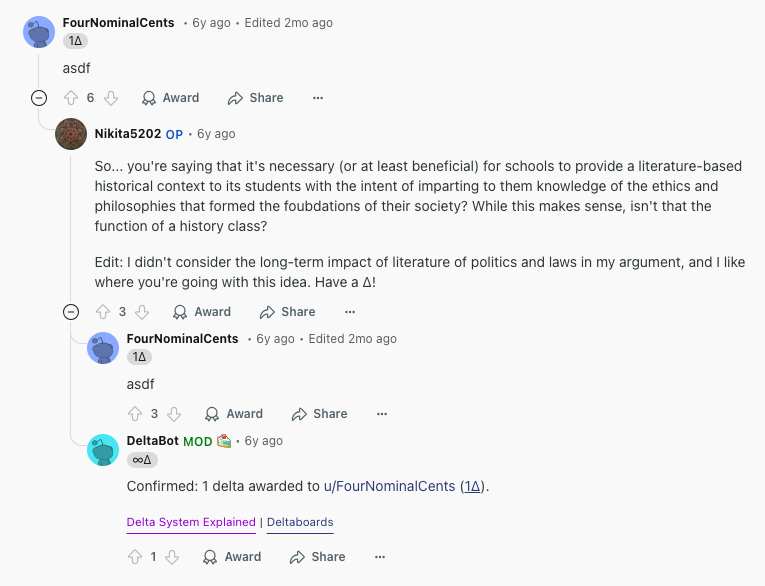

The comment is marked as "convincing", however, it has no meaning. We see that the comment was awarded a delta 6 years ago, and was edited 2 months ago, so the author probably removed a more-meaningful text. This comment has no value for us, and it may interfer the model later, so we will remove it from the dataframe.



In [ ]:
comments_df = comments_df.drop(index=3841)


# ６. Feature engineering


We would like to find the characteristics of convincing arguments. We will create several features that can be helpful in identifying a convincing argument, and the new features can later be used in a predictive model.

## 6.1 Sentiment Analysis

Check whether sentiment (positive/negative tone) correlates with persuasiveness

### TextBlob

In [ ]:
# prompt: take the column comments_df['thread_text'] and the column comments_df['final_comment'] and return a new list / column in which each thread is concatenated to the appropriate final comment with a space in between them

def concatenate_columns(df):
  """
  Concatenates 'thread_text' and 'final_comment' columns with a space in between.

  Args:
    df: pandas DataFrame with 'thread_text' and 'final_comment' columns.

  Returns:
    A new column named 'concatenated_text' with the concatenated text.
    Returns the original DataFrame if either column is missing.
  """
  if not all(col in df.columns for col in ['thread_text', 'final_comment']):
    print("Error: 'thread_text' or 'final_comment' column not found in DataFrame.")
    return df

  df['concatenated_text'] = df['thread_text'] + "\n" + separator_token + "\n" + df['final_comment']
  return df

# Example usage (assuming 'comments_df' is your DataFrame):
# comments_df = concatenate_columns(comments_df)
# print(comments_df.head())


In [ ]:
from textblob import TextBlob

# Function to calculate sentiment polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity  # Range: -1 (negative) to +1 (positive)

comments_df["sentiment"] = (comments_df['thread_text'] + "\n" + separator_token + "\n" + comments_df['final_comment']).apply(get_sentiment)

comments_df.describe()

,is_convincing,sentiment
count,4089.000000,4089.000000
mean,0.148692,0.089395
std,0.355828,0.175789
min,0.000000,-1.000000
25%,0.000000,0.000000
50%,0.000000,0.085894
75%,0.000000,0.173772
max,1.000000,1.000000


In [ ]:
def plot_feature(feature_name, feature_disp_name, bin_width, width = 0.4, figsize=(12, 6)):
  import matplotlib.pyplot as plt

  min_val = comments_df[feature_name].min()
  max_val = comments_df[feature_name].max()

  bins = [min_val + i * bin_width for i in range(int((max_val - min_val) / bin_width) + 2)]

  # Count convincing and non-convincing comments in each bin
  convincing_counts = []
  non_convincing_counts = []
  bin_labels = []

  for i in range(len(bins) - 1):
      lower_bound = bins[i]
      upper_bound = bins[i+1]
      bin_comments = comments_df[(comments_df[feature_name] >= lower_bound) & (comments_df[feature_name] < upper_bound)]
      convincing_count = bin_comments[bin_comments['is_convincing'] == 1].shape[0]
      non_convincing_count = bin_comments[bin_comments['is_convincing'] == 0].shape[0]
      convincing_counts.append(convincing_count)
      non_convincing_counts.append(non_convincing_count)
      bin_labels.append(f'{lower_bound:.2f}-{upper_bound:.2f}')


  # Plotting the histogram
  x = range(len(bin_labels))

  fig, ax = plt.subplots(figsize=figsize)
  rects1 = ax.bar([i - width/2 for i in x], convincing_counts, width, label='Convincing', color='green')
  rects2 = ax.bar([i + width/2 for i in x], non_convincing_counts, width, label='Non-Convincing', color='red')

  # Add labels to the bars
  def autolabel(rects):
      for rect in rects:
          height = rect.get_height()
          ax.annotate('{}'.format(height),
                      xy=(rect.get_x() + rect.get_width() / 2, height),
                      xytext=(0, 3),  # 3 points vertical offset
                      textcoords="offset points",
                      ha='center', va='bottom')

  autolabel(rects1)
  autolabel(rects2)


  ax.set_xlabel(f'{feature_disp_name} Bin')
  ax.set_ylabel('Number of Comments')
  ax.set_title(f'Number of Convincing and Non-Convincing Comments per {feature_disp_name} Bin')
  ax.set_xticks(x)
  ax.set_xticklabels(bin_labels)
  ax.legend()
  plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
  plt.tight_layout()
  plt.show()

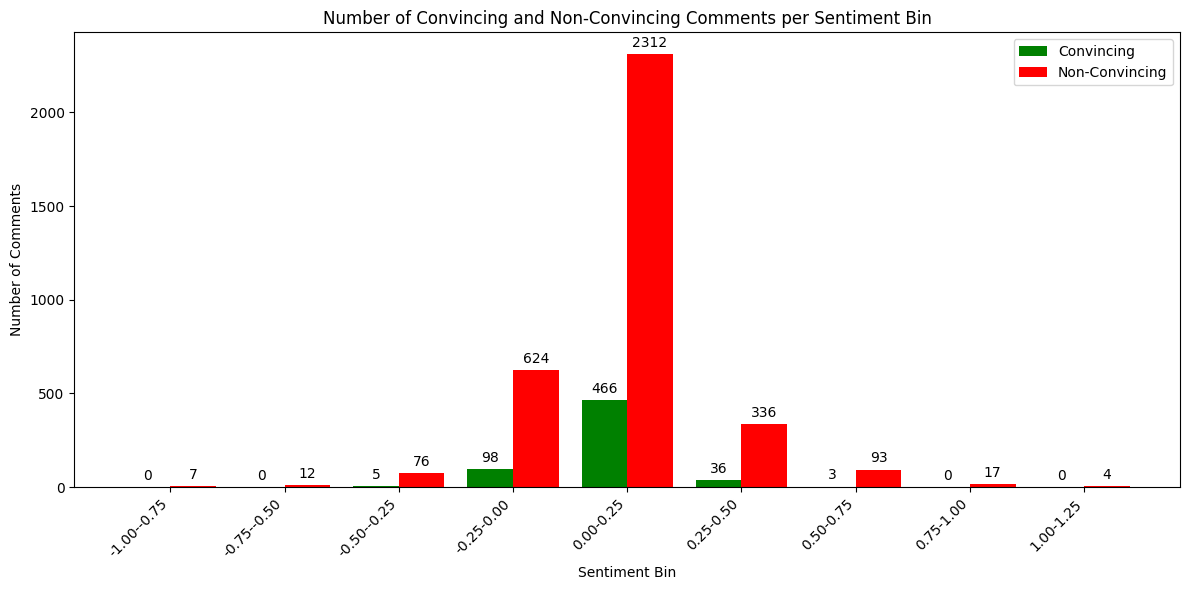

In [ ]:
plot_feature('sentiment', 'Sentiment', 0.25)

In [ ]:
def show_example_comments():
  # Find 3 comments with minimal sentiment
  min_sentiment_comments = comments_df.nsmallest(3, 'sentiment')
  for index, row in min_sentiment_comments.iterrows():
      print(f"Minimal Sentiment Comment (Sentiment: {row['sentiment']:.2f}):")
      print(f"  Thread Text: {row['thread_text']}")
      print(f"  Final Comment: {row['final_comment']}")
      print("-" * 20)

  # Find 3 comments with maximal sentiment
  max_sentiment_comments = comments_df.nlargest(3, 'sentiment')
  for index, row in max_sentiment_comments.iterrows():
      print(f"Maximal Sentiment Comment (Sentiment: {row['sentiment']:.2f}):")
      print(f"  Thread Text: {row['thread_text']}")
      print(f"  Final Comment: {row['final_comment']}")
      print("-" * 20)

In [ ]:
show_example_comments()

Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: 
  Final Comment: If noone can decide what is evil then there's nothing evil about schadenfreude
--------------------
Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: 
  Final Comment: You're looking for r/TrueUnpopularOpinion. Some shocking opinions, but that's the nature of the beast.
--------------------
Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: 
  Final Comment: Thats probably the worst example ever
--------------------
Maximal Sentiment Comment (Sentiment: 1.00):
  Thread Text: 
  Final Comment: I wouldn’t have thought of that, but I feel it captures the sentiment perfectly.
--------------------
Maximal Sentiment Comment (Sentiment: 1.00):
  Thread Text: What would be the alternative?  An anarchosyndicalist commune, with someone taking turns to act as a sort of executive officer of the week?  


  Final Comment: > What would be the alternative? An anarchosyndicalist commune, with someone ta

The TextBlob way of identifying the sentiment is based on scoring each word in the text and taking the average score. This approach is less suitable for texts as long as ours. As we can see in the example texts, the sentiment is not identified very well, so we will try a more sophisticated approach, the VADER module.

### VADER module

In [ ]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.9 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(text)['compound']

In [ ]:
comments_df["sentiment"] = (comments_df['thread_text'].fillna("") + "\n" + separator_token + "\n" + comments_df['final_comment']).apply(get_sentiment)

comments_df.describe()

,is_convincing,sentiment
count,4089.000000,4089.000000
mean,0.148692,0.139704
std,0.355828,0.689100
min,0.000000,-0.999900
25%,0.000000,-0.504000
50%,0.000000,0.226300
75%,0.000000,0.821100
max,1.000000,0.999700


In [ ]:
show_example_comments()

Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: Just wanted to chime in with a tiny part. If your living conditions weren't great, or even good, that doesn't give you the right to take it out on people.

I'm a child of war and as shocking that may sound to someone - it gives zero free passing in court. Having PTSD from it is a different thing, but even in cases where someone with PTSD commits a crime he's still held accountable.

Living in a war zone as a child does affect you, but it's not a free pass for being an ass.
[SEP]
He wasn't just *"walking around angry"*.

He had a bat. 

He waited to *be attacked*.

He was ready to ~~hurt~~ kill *any black man* for something one (maybe!) did.

He did it for a *whole week*.


That's really calculated and not something irrational he did while angry. He was making sure that *when* he kills **random black person** it will be said persons fault and LN would play it as self defence. 

Growing up in a war zone does fuck you up, but th

Here we see better classification of sentiment. The negative examples include rude language while the positive examples demonstrate a pleasent style.

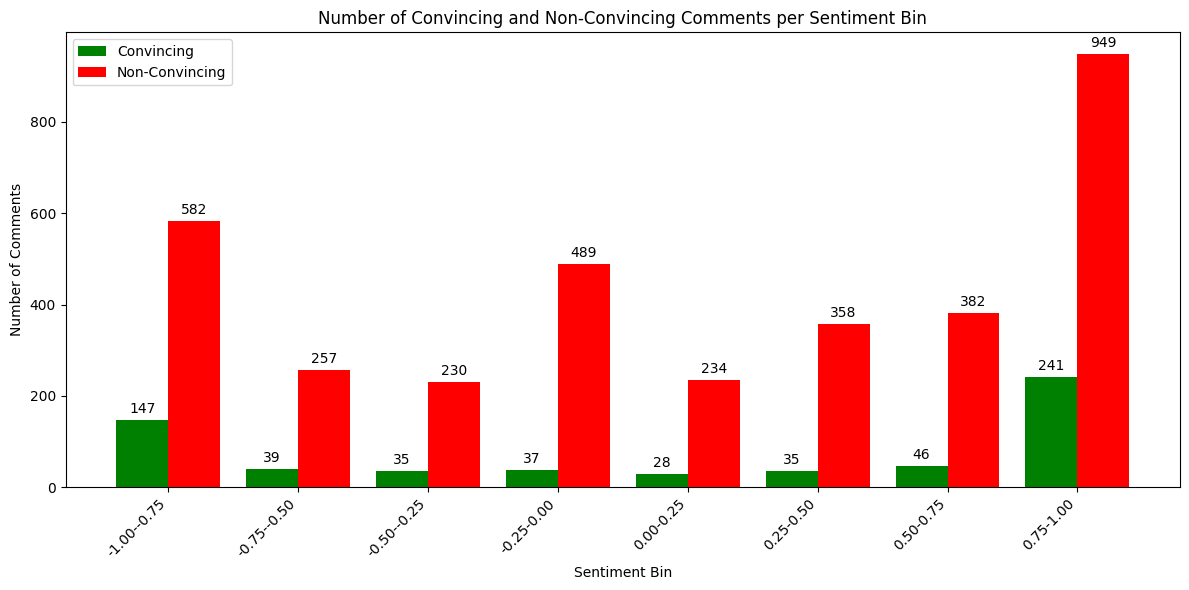

In [ ]:
plot_feature('sentiment', 'Sentiment', 0.25)

We see that most of the convincing comments are either very positive or very negative, while a less extreme sentiment resulted smaller amount of convincing comments.

As for the non-convincing comments, we see that althogh most of the comments were very positive, they were not convincing, which may be counter-intuitive.

Generally speaking, it doesn't see that there is a direct connection between the sentiment and the comment being convincing or not. Nonetheless, we can use the sentiment as a feature to our model.

## 6.2 Tone
We would like to create a feature for the tone of the text. The tone can be, for example, logical, passionate, humorous etc.
We will try a pre-trained model based on RoBERTa.

### RoBERTa based model

In [ ]:
from transformers import pipeline
classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")

def get_tone(text):
    return classifier(text, truncation=True, padding=True)  # since our texts may be long and Roberta is limited to 512 tokens, we truncate any excessive text

text = get_comment_and_thread(comment_first=True) # the text may be truncated so we put the convincing comment first - it's more important
comments_df["tone"] = text.apply(get_tone)


Device set to use cpu


In [ ]:
print(comments_df['tone'])


0       [{'label': 'neutral', 'score': 0.8615567088127...
1       [{'label': 'anger', 'score': 0.8864083886146545}]
2       [{'label': 'neutral', 'score': 0.6452071666717...
3        [{'label': 'fear', 'score': 0.5824066400527954}]
4       [{'label': 'neutral', 'score': 0.8495560884475...
                              ...                        
4084     [{'label': 'fear', 'score': 0.6567506194114685}]
4085    [{'label': 'neutral', 'score': 0.9447934031486...
4086      [{'label': 'joy', 'score': 0.2893628180027008}]
4087    [{'label': 'neutral', 'score': 0.9226306080818...
4088    [{'label': 'neutral', 'score': 0.5850099325180...
Name: tone, Length: 4089, dtype: object


In [ ]:
print(comments_df['tone'][0])

[{'label': 'neutral', 'score': 0.8615567088127136}]


In [ ]:
comments_df['tone_label'] = comments_df['tone'].apply(lambda x: x[0]['label'] if isinstance(x, list) and len(x) > 0 else None)

In [ ]:
comments_df['tone_label']

,tone_label
0,neutral
1,anger
2,neutral
3,fear
4,neutral
...,...
4084,fear
4085,neutral
4086,joy
4087,neutral


In [ ]:
import matplotlib.pyplot as plt

def plot_category_histogram(df, column_name, display_name):
    """
    Plots a histogram showing the distribution of convincing and non-convincing comments for each category in the specified column.

    Args:
        df: The pandas DataFrame containing the data.
        column_name: The name of the column containing the categories.
    """

    convincing_counts = df[df['is_convincing'] == 1][column_name].value_counts()
    non_convincing_counts = df[df['is_convincing'] == 0][column_name].value_counts()

    categories = convincing_counts.index.union(non_convincing_counts.index)
    convincing_counts = convincing_counts.reindex(categories, fill_value=0)
    non_convincing_counts = non_convincing_counts.reindex(categories, fill_value=0)

    width = 0.4
    x = range(len(categories))
    fig, ax = plt.subplots(figsize=(12,6))
    rects1 = ax.bar([i - width/2 for i in x], convincing_counts, width, label='Convincing', color='green')
    rects2 = ax.bar([i + width/2 for i in x], non_convincing_counts, width, label='Non-Convincing', color='red')

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate('{}'.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')
    autolabel(rects1)
    autolabel(rects2)

    ax.set_xlabel(display_name)
    ax.set_ylabel('Number of Comments')
    ax.set_title(f'Number of Convincing and Non-Convincing Comments per {display_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


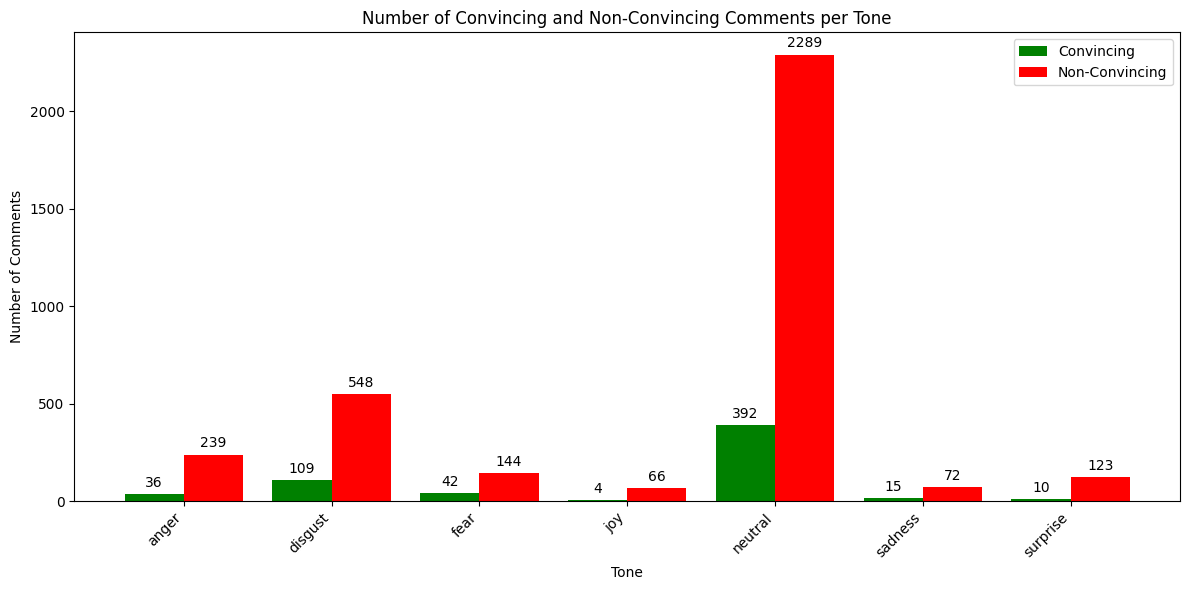

In [ ]:
plot_category_histogram(comments_df, 'tone_label', 'Tone')


In [ ]:
def show_tone_examples(tone_label):
  for index, row in comments_df[comments_df['tone'].apply(lambda x: isinstance(x, list) and len(x) > 0 and x[0]['label'] == tone_label and x[0]['score'] > 0.85)].iterrows():
    print(f"Example for {tone_label}:")
    print(row['final_comment'])
    print("-" * 20)
    break

In [ ]:
show_tone_examples("fear")
show_tone_examples("joy")
show_tone_examples("surprise")


Example for fear:
Im not really here to convince you that god exists but i will say diamonds are made through preassure i could never imagine what your situation feels like but just remember that almost every great person whether in history or just in everday life had to overcome something absolutely horrible this is not the end of the story just a roadblock and just remember that if you manage to overcome this situation you which is absolutely possible you will undoubtedly become someones who has transcended modern day suffering
--------------------
Example for joy:
At the very least I have learnt something new, and posetive, about candidate im not a big fan of. Thanks, it makes me a bit more hopeful
--------------------
Example for surprise:
Same here. Which honestly I think is kind of funny since everyone is willing to put down antivaxxers for all the damages they cause by not vaccinating their kids. It seems a little strange that there isn't some massive proof that their children a

We are not very satisfied with the results of classification, it seems that the classification is not very accurate and we want to try a different approach, using Google AI Studio.

### Google's Gemini

In [ ]:
!pip install -q langchain langchain-openai langchain-core langchain-google-vertexai langchain-openai pydantic
!pip install google-cloud
!pip install google-cloud-aiplatform
!pip install python-dotenv

In [ ]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/drive/MyDrive/תואר שני/שנה ב סמסטר א/כריית טקסטים/פרויקט סיום/gen-lang-client-0273205429-e512953a3e5e.json"

from pathlib import Path
# The .env file contains the 'GEMINI_API_KEY' environment variable
dotenv_path = Path("/content/drive/MyDrive/תואר שני/שנה ב סמסטר א/כריית טקסטים/פרויקט סיום/.env")

from dotenv import load_dotenv
load_dotenv(dotenv_path)


True

In [ ]:
from google.cloud import aiplatform

aiplatform.init(project='gen-lang-client-0273205429', location='us-central1')

from langchain_google_vertexai import VertexAI,ChatVertexAI
llm_gemini = ChatVertexAI(
    model_name="gemini-1.5-flash-002",
)

In [ ]:
# let's try with an example text taken randomly from our data set:
test_text = comments_df.iloc[95]['final_comment']
test_text

'Im not really here to convince you that god exists but i will say diamonds are made through preassure i could never imagine what your situation feels like but just remember that almost every great person whether in history or just in everday life had to overcome something absolutely horrible this is not the end of the story just a roadblock and just remember that if you manage to overcome this situation you which is absolutely possible you will undoubtedly become someones who has transcended modern day suffering'

In [ ]:
user_prompt_prefix = """Analyze the tone of the following text and classify it as one of the following: Logical, Passionate, Humorous, Sarcastic, Neutral, or Other.
Your answer should be just a single word, which is the tone.
Text:
"""

In [ ]:
user_prompt = user_prompt_prefix + test_text

response = llm_gemini.invoke(user_prompt)
classification = response.content.strip()
print(classification)

Passionate


In [ ]:
comments_df['tone_google'] = None

In [ ]:
def get_tone_from_google_ai(row):
  if isinstance(row['thread_text'], str):
    text = row['thread_text'] + "\n" + row['final_comment']
  else:
    text = row['final_comment']

  user_prompt = user_prompt_prefix + text
  response = llm_gemini.invoke(user_prompt)
  classification = response.content.strip()
  print(f"row {row.name} classified as {classification}")
  return classification

In [ ]:
import time

counter = 0
# this loop can be executed multiple times until all entries were classified
for index, row in comments_df.iterrows():
  if counter == 5:
    time.sleep(3)  # add some sleep so we don't get out of quota
    counter = 0
  if pd.isna(row['tone_google']):  # calculate only if wasn't calculated yet
      comments_df.at[index, 'tone_google'] = get_tone_from_google_ai(row)
      counter += 1

In [ ]:
none_count = comments_df['tone_google'].isna().sum()
if none_count == 0:
  print("All entries were classified!")
else:
  print(f"{none_count} entries still need to be classified out of {len(comments_df)}")

All entries were classified!


In [ ]:
comments_df['tone_google'].head(20)

,tone_google
0,Logical
1,Logical
2,Logical
3,Logical
4,Logical
5,Logical
6,Logical
7,Logical
8,Neutral
9,Logical


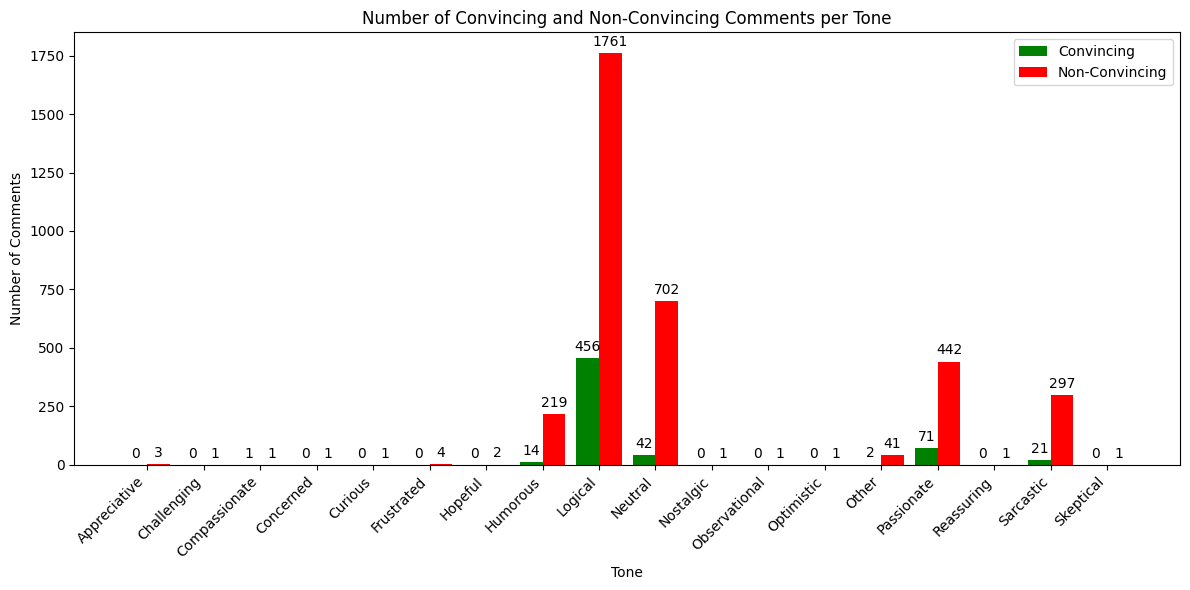

In [ ]:
plot_category_histogram(comments_df, 'tone_google', 'Tone')

In [ ]:
def show_tone_examples(tone_label):
  print(f"Example for {tone_label}:")
  print(comments_df[comments_df['tone_google'] == tone_label].iloc[0]['final_comment'])
  print("-" * 20)

show_tone_examples("Humorous")
show_tone_examples("Sarcastic")
show_tone_examples("Passionate")

Example for Humorous:
> "oi, get a room, there's people here need a piss"

I'm dying.
--------------------
Example for Sarcastic:
Someone standing outside the door screaming at you to hurry the hell up wouldn't be enough to deter you?  I mean, who the hell cares if there is no line, but if others are waiting, they will not be patient for anyone to have sex.
--------------------
Example for Passionate:
My daughter is 15. She does not tolerate bullying at all (my son is autistic & she spent her early years around kids w/disabilities). If she sees it happen, my girl stands up! But she also asks why is the bully a bully? What is happening in that person's life that would lead them to behave that way. Then, she befriends them. To date, bullies that became her friends had the following happening at the time :

-One was being neglected at home to the point we called CPS
-One had parents going thru a terrible divorce
-One had a mom that was incredibly cruel

There are mean people out there. Bu

## 6.3 Style - formal / informal
We would like to create a feature for the style of the text, in other words is it formal or informal text.

For this we will use the model facebook/bart-large-mnli that has been trained on a wide range of general text categories.

We will use this model with zero-shot classification, by defining labels "formal" and "informal" and classify the texts into these categories.

In [ ]:
import re
def do_calc_feature(feature, func, remove_urls=False, switch_order=False):
  for index, row in comments_df.iterrows():
    if pd.isna(row[feature]):  # calculate only if wasn't calculated yet
      print(f"Calculating {feature} for index {index}")
      if not isinstance(row['thread_text'], str):
        text = row['final_comment']
      elif switch_order:
        text = row['final_comment'] + "\n" + row['thread_text']
      else:
        text = row['thread_text'] + "\n" + row['final_comment']

      if remove_urls:
        text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
      comments_df.at[index, feature] = func(text)

In [ ]:
from transformers import pipeline

# Load zero-shot classification pipeline
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

candidate_labels = ["formal", "informal"]

def get_style(text):
    return classifier(text, candidate_labels)


In [ ]:
comments_df['style'] = None

In [ ]:
do_calc_feature("style", get_style)

In [ ]:
comments_df['style'].iloc[0]

{'sequence': 'I agree with mercy. But sometimes mercy can rob justice. There comes a time when logic, reasoning, and understanding aren’t enough. The trick is recognizing when a situation like that really comes about. In any case, a man or woman incapable of biting back isn’t really capable of doing a whole lot of good in the world. ',
 'labels': ['formal', 'informal'],
 'scores': [0.5104171633720398, 0.4895828664302826]}

In [ ]:
import json
import ast

def convert_string_to_json(string):
  data = ast.literal_eval(string)
  data_obj = json.dumps(data, indent=4)
  return json.loads(data_obj)

def get_style_label(style):
  if isinstance(style, str):
    style = convert_string_to_json(style)
  return style['labels'][style['scores'].index(max(style['scores']))]

In [ ]:
get_style_label(comments_df['style'].iloc[0])

'formal'

In [ ]:
comments_df['style_label'] = comments_df['style'].apply(get_style_label)

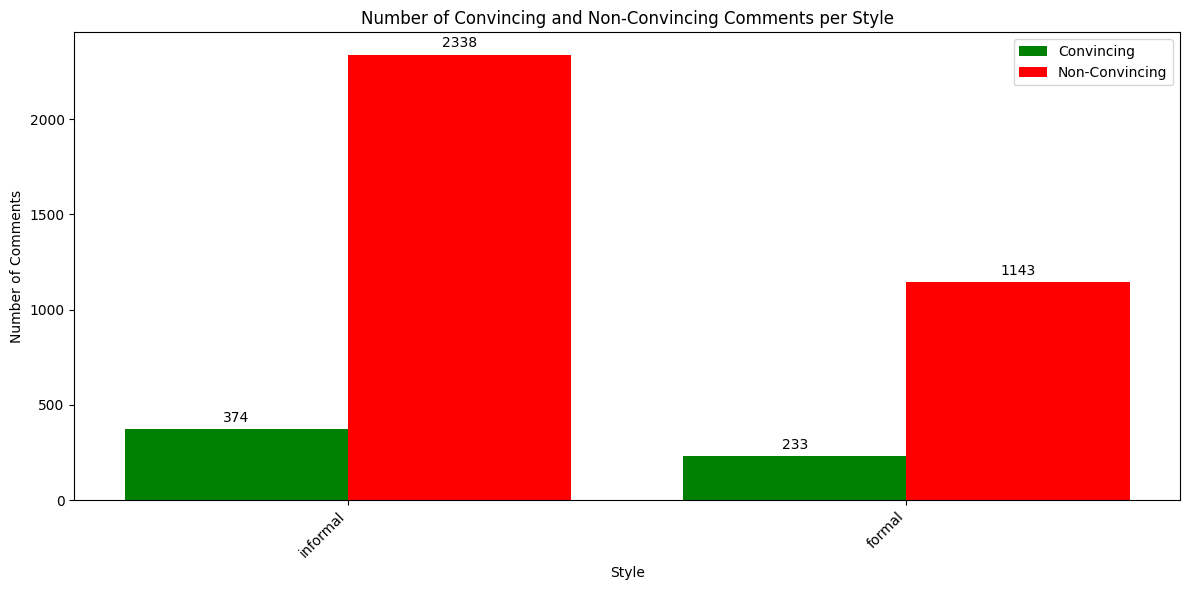

In [ ]:
plot_category_histogram(comments_df, 'style_label', 'Style')

We see that most of the comments are informal, which makes sense for this type of communication.

In [ ]:
def show_style_example(style):
  print(f"Example for {style}:")
  for _, row in comments_df[comments_df['style_label'] == style].iterrows():
    style = convert_string_to_json(row['style'])
    if max(style['scores']) > 0.95:
      print(row['final_comment'])
      print("-" * 20)
      break

show_style_example("formal")
show_style_example("informal")

Example for formal:
Yup, this is the law where I am.  Employer is required to give notice, or the same amount of pay in lieu of notice.  Most employers choose to give pay as soon-to-be laid off employees tend to be poor employees.

The only exception is if the employee is fired for cause -- but the burden is on the employer to show cause if challenged.
--------------------
Example for informal:
Yeah, that sounds like a made-up reason to me.
--------------------


## 6.4 Rhetorical means
**Rhetorical means** refer to the strategies and techniques used to persuade or influence an audience in communication. They are central to the art of rhetoric and can be categorized into three main types: **ethos**, **pathos**, and **logos**. Together, these rhetorical means form the foundation of persuasive communication.

**Ethos** appeals to the speaker's credibility and character, aiming to establish trust with the audience.

**Pathos** focuses on evoking emotions, such as sympathy or anger, to connect with the audience on a personal level.

**Logos**, on the other hand, relies on logic and reasoning, using facts, statistics, and logical arguments to persuade the audience.

We would like to create feature with the amount of each rhetorical mean in each text.

Empath is an open-source text analysis library that categorizes words into psychologically meaningful themes, allowing users to extract insights about emotions, topics, and rhetorical strategies from text. We will use this library to calculate scores for each rhethorical mean in our data set.

In [ ]:
!pip install empath

In [ ]:
pathos_categories = ['hate', 'cheerfulness', 'aggression', 'envy', 'anticipation', 'fear', 'nervousness', 'horror', 'suffering', 'pride', 'sadness', 'optimism', 'irritability', 'surprise', 'exasperation', 'zest', 'confusion', 'love', 'sympathy', 'rage', 'emotional', 'joy', 'affection', 'shame', 'torment', 'anger', 'disappointment', 'pain', 'timidity', 'negative_emotion', 'positive_emotion', 'contentment']
ethos_categories = ['office', 'occupation', 'government', 'royalty', 'wealthy', 'journalism', 'banking', 'leader', 'independence', 'dominant_heirarchical', 'military', 'dominant_personality', 'science', 'work', 'philosophy', 'law', 'achievement']
logos_categories = ['money', 'medical_emergency', 'crime', 'dispute', 'government', 'school', 'computer', 'college', 'business', 'driving', 'internet', 'programming', 'economics', 'politics', 'technology', 'negotiate', 'payment']

In [ ]:
comments_df['ethos_score'] = None
comments_df['pathos_score'] = None
comments_df['logos_score'] = None

In [ ]:
from empath import Empath
import pandas as pd

lexicon = Empath()

def compute_rhetorical_scores():
  for index, row in comments_df.iterrows():
    if pd.isna(row['ethos_score']) or pd.isna(row['pathos_score']) or pd.isna(row['logos_score']):  # calculate only if wasn't calculated yet
      print(f"Calculating rhethorical means for index {index}")
      if isinstance(row['thread_text'], str):
        text = row['thread_text'] + "\n" + row['final_comment']
      else:
        text = row['final_comment']

      analysis = lexicon.analyze(text, normalize=True)  # Normalize to percentage

      ethos_score = sum(analysis[cat] for cat in ethos_categories)
      pathos_score = sum(analysis[cat] for cat in pathos_categories)
      logos_score = sum(analysis[cat] for cat in logos_categories)

      comments_df.at[index, 'ethos_score'] = ethos_score
      comments_df.at[index, 'pathos_score'] = pathos_score
      comments_df.at[index, 'logos_score'] = logos_score

In [ ]:
compute_rhetorical_scores()

Let's plot the distribution of each rhethorical mean in the dataset:

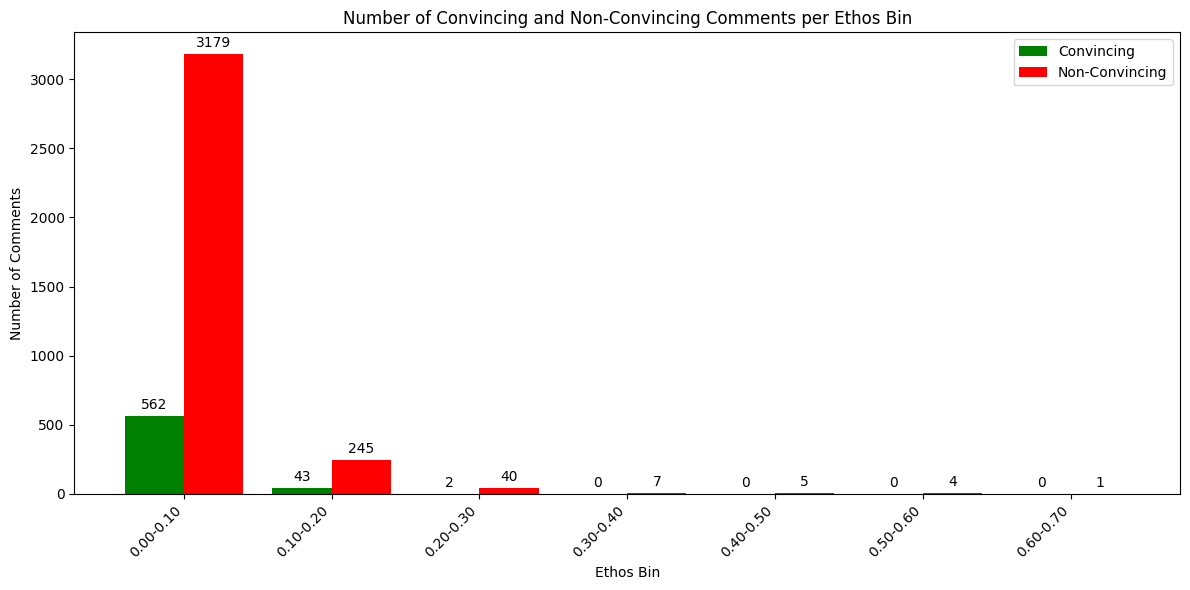

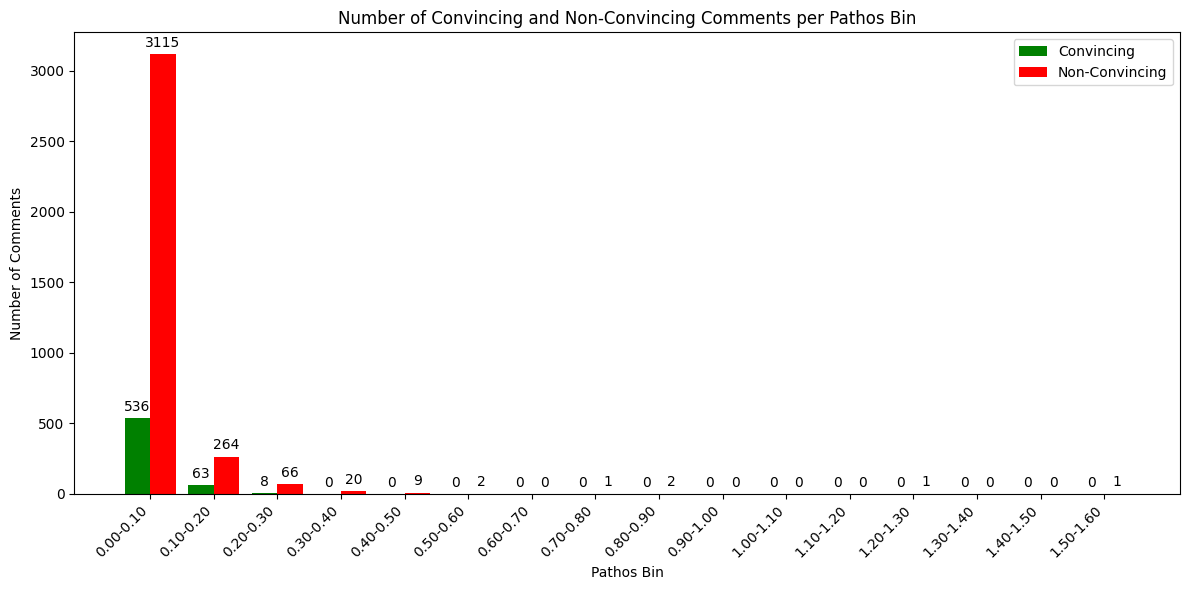

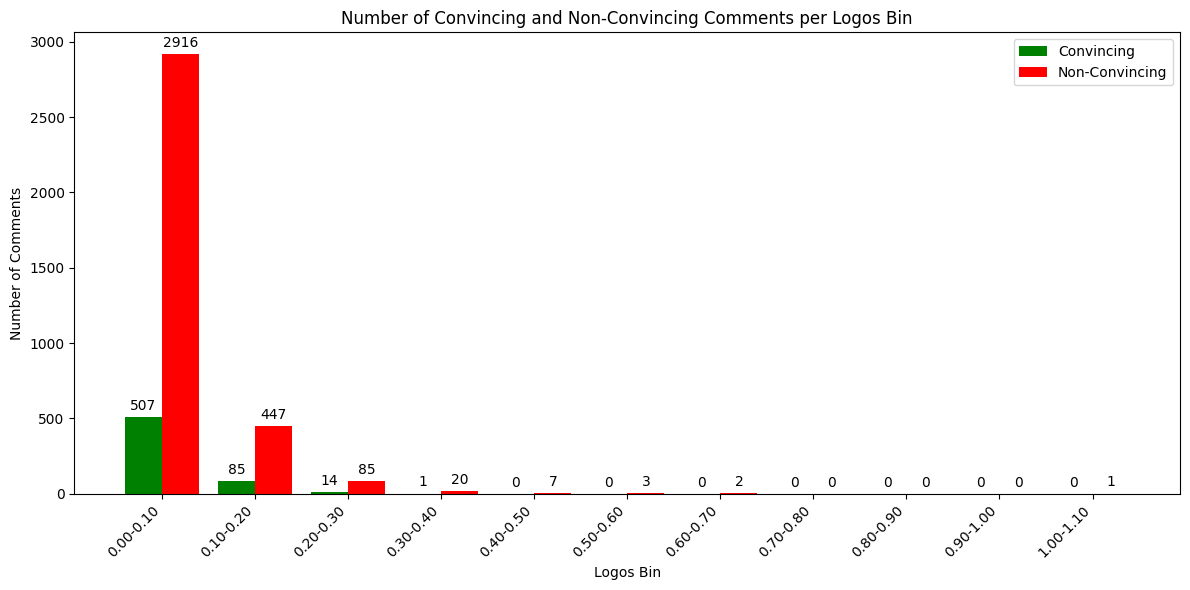

In [ ]:
plot_feature('ethos_score', 'Ethos', 0.10)
plot_feature('pathos_score', 'Pathos', 0.10)
plot_feature('logos_score', 'Logos', 0.10)

Examples:

In [ ]:
def show_rhethorical_mean_example(feature_name):
  for index, row in comments_df[comments_df[feature_name] > 0.85].iterrows():
    print(f"Example for {feature_name} = {row[feature_name]}:")
    print(row['final_comment'])
    print("-" * 20)
    break

show_rhethorical_mean_example('ethos_score')
show_rhethorical_mean_example('pathos_score')
show_rhethorical_mean_example('logos_score')

Example for pathos_score = 1.2727272727272727:
Ahhh...true feelings, like the feeling you want a new beach house.
--------------------
Example for logos_score = 1.0:
Ad revenue :(
--------------------


We see that the results are not reliable, therefore, we won't include this feature in the final model.

It would have been interesting to try to identify the rhethorical means using LLMs such as Gemini or Chat GPT, but due to time limitations, we will not include this in the current work.

## 6.5 Adjective-Adverb Ratio

The **Adjective-Adverb Ratio**, also called the **Descriptive Density Ratio** measures the proportion of adjectives and adverbs in a text relative to the total word count. A higher ratio indicates a more expressive or emotionally charged writing style, while a lower ratio suggests a more concise, factual, and objective tone.

In [ ]:
import spacy

nlp = spacy.load('en_core_web_sm')

def get_adjective_adverb_ratio(text):
  doc = nlp(text)
  adjectives = [token.text for token in doc if token.pos_ == 'ADJ']
  adverbs = [token.text for token in doc if token.pos_ == 'ADV']
  return len(adjectives) / len(adverbs) if len(adverbs) > 0 else np.inf

In [ ]:
comments_df['adj_adv_ratio'] = None

In [ ]:
do_calc_feature("adj_adv_ratio", get_adjective_adverb_ratio)

In [ ]:
import numpy as np
comments_df['adj_adv_ratio_edited'] = comments_df['adj_adv_ratio'].replace(np.inf, 0)

In [ ]:
comments_df['adj_adv_ratio_edited'].describe()

,adj_adv_ratio_edited
count,4088.000000
mean,1.330311
std,1.204544
min,0.000000
25%,0.666667
50%,1.116111
75%,1.740622
max,15.000000


We want to plot the results. The max result, excluding infinity is 15, so we will replace every instance of infinity by 17.

In [ ]:
comments_df['adj_adv_ratio_edited'] = comments_df['adj_adv_ratio'].replace(np.inf, 17)

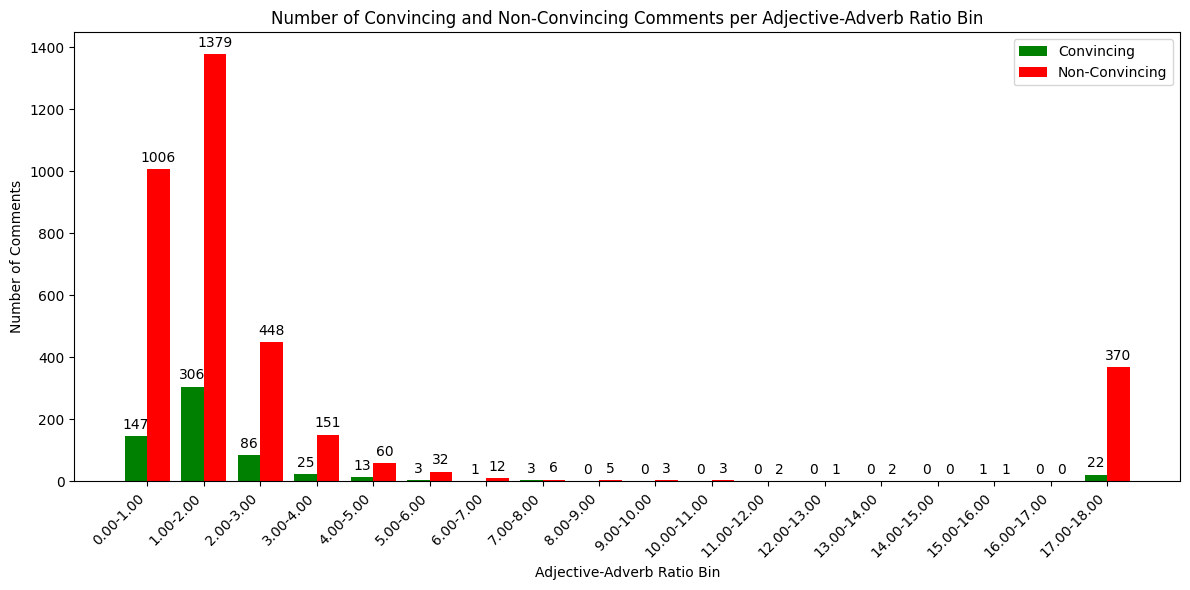

In [ ]:
plot_feature('adj_adv_ratio_edited', 'Adjective-Adverb Ratio', 1)

In [ ]:
# Drop the 'adj_adv_ratio' column
comments_df = comments_df.drop('adj_adv_ratio', axis=1)

# Rename 'adj_adv_ratio_edited' to 'adj_adv_ratio'
comments_df = comments_df.rename(columns={'adj_adv_ratio_edited': 'adj_adv_ratio'})


In [ ]:

import numpy as np

max_adj_adv_ratio_row = comments_df.loc[comments_df['adj_adv_ratio'].idxmax()]
print(f"Example for high Adj/Adv ratio ({max_adj_adv_ratio_row['adj_adv_ratio']}):")
print(max_adj_adv_ratio_row['final_comment'])
print("-" * 20)

min_adj_adv_ratio_row = comments_df.loc[comments_df['adj_adv_ratio'].idxmin()]
print(f"Example for low Adj/Adv ratio ({min_adj_adv_ratio_row['adj_adv_ratio']}):")
print(min_adj_adv_ratio_row['final_comment'])
print("-" * 20)


Example for high Adj/Adv ratio (inf):
Someone standing outside the door screaming at you to hurry the hell up wouldn't be enough to deter you?  I mean, who the hell cares if there is no line, but if others are waiting, they will not be patient for anyone to have sex.
--------------------
Example for low Adj/Adv ratio (0.0):
> "oi, get a room, there's people here need a piss"

I'm dying.
--------------------


Generally, we can say that:
* High Adjective-to-Adverb Ratio
  * More adjectives than adverbs
  * The text is descriptive and vivid, often used in storytelling and persuasive writing to create strong imagery and appeal to emotions.
  * May indicate a focus on ethos (credibility) and pathos (emotion) by painting a compelling picture.

* Low Adjective-to-Adverb Ratio
  * More adverbs than adjectives
  * The text is action-driven and dynamic, emphasizing how actions are performed, often found in arguments, speeches, or instructional writing.
  * May indicate a focus on logos (logical reasoning) and pathos (emotional appeal) by emphasizing how actions happen.

* Balanced Ratio
  * More or less the same amount of adjectives and adverbs
  * The text is neutral and precise, commonly seen in academic, formal, or news writing, aiming for a mix of credibility, logic, and emotional appeal.
  * May indicate a mix of ethos (credibility), logos (logic), and pathos (emotion) in persuasion.



We see that in our dataset, the texts tend to have high ratio of Adjective-to-Adverb.

## 6.6 Readability

Readability is a crucial feature in the feature engineering of convincing and non-convincing texts because it directly impacts how easily the audience can understand and engage with the message. A highly readable text is often more persuasive, as it allows the reader to quickly grasp the key points and emotional appeals without feeling overwhelmed or lost in complex language.

One of the widely used metrics for estimating readability is the **Flesch-Kincaid Readability Tests**.

The **Flesch-Kincaid Readability Tests** provide a score based on sentence length and word complexity, with the result indicating the U.S. school grade level required to understand the text. A lower score suggests a more accessible text, which is often more persuasive.

We will calculate:
* Flesch-Kincaid Grade Level: This score gives an approximation of the U.S. school grade level needed to understand the text. A higher value means more complex language.
* Flesch Reading Ease: This score indicates how easy the text is to read. Higher values (above 60) indicate easier text, while lower values suggest more complex, harder-to-read text.

In [ ]:
!pip install textstat

### Flesh Kincaid Grade Level

In [ ]:
comments_df['fk_grade_level'] = None

In [ ]:
import textstat
do_calc_feature("fk_grade_level", lambda text: textstat.flesch_kincaid_grade(text), remove_urls=True)

In [ ]:
comments_df['fk_grade_level'].head()

,fk_grade_level
0,7.7
1,5.2
2,12.8
3,8.0
4,6.0


The datatype is object, we will convert it to a number.

In [ ]:
comments_df['fk_grade_level_converted'] = pd.to_numeric(comments_df['fk_grade_level'], errors='coerce')

In [ ]:
comments_df['fk_grade_level_converted'].describe()

,fk_grade_level_converted
count,4088.000000
mean,9.107094
std,3.889445
min,-15.700000
25%,7.000000
50%,8.900000
75%,11.000000
max,70.300000


We see that there's an unexpected result of -15 in the minimum, let's inspect the comments that resulted a value below 0:

In [ ]:
comments_df[comments_df['fk_grade_level_converted'] < 0]

,original_post,thread_text,final_comment,is_convincing,final_comment_id,cleaned_final_comment,cleaned_thread_text,cleaned_original_post,sentiment,tone,...,tone_google,style,ethos_score,pathos_score,logos_score,adj_adv_ratio,adj_adv_ratio_edited,fk_grade_level,fk_reading_ease,fk_grade_level_converted
150,CMV: Mike Bloomberg's campaign is proof that t...,NaN,I saved your post it was so good. Hear hear to...,0,fjlcge6,saved your post it was so good Hear hear to that,nan,CMV Mike Bloombergs campaign is proof that the...,0.7804,"[{'label': 'joy', 'score': 0.5279616713523865}]",...,Passionate,{'sequence': 'I saved your post it was so good...,0.000000,0.000000,0.083333,1.0,1.0,-1.5,116.15,-1.5
475,CMV: if great britain not giving the 13 US col...,NaN,Good bot.,0,g712ly1,Good bot,nan,CMV if great britain not giving the 13 US colo...,0.4404,"[{'label': 'neutral', 'score': 0.9472147822380...",...,Neutral,"{'sequence': 'Good bot.', 'labels': ['informal...",0.000000,0.000000,0.000000,inf,17.0,-3.1,120.21,-3.1
482,CMV: if great britain not giving the 13 US col...,NaN,It’s not,0,g6yqsz5,Its not,nan,CMV if great britain not giving the 13 US colo...,0.0000,"[{'label': 'neutral', 'score': 0.9247686862945...",...,Other,"{'sequence': 'It’s not', 'labels': ['informal'...",0.000000,0.000000,0.000000,inf,17.0,-3.1,120.21,-3.1
546,cmv: Ban on sleeping in vehicles is just targe...,NaN,"RIP, man. Seemed like a great dude.",0,g7gsxzl,RIP man Seemed like great dude,nan,cmv Ban on sleeping in vehicles is just target...,0.7650,"[{'label': 'sadness', 'score': 0.6535121202468...",...,Neutral,"{'sequence': 'RIP, man. Seemed like a great du...",0.142857,0.142857,0.000000,inf,17.0,-1.2,115.13,-1.2
573,CMV: The white teen who said the n word on a S...,NaN,This is a great point tbh,0,gidgtax,This is great point tbh,nan,CMV The white teen who said the word on Snap...,0.6249,"[{'label': 'joy', 'score': 0.538154661655426}]",...,Neutral,"{'sequence': 'This is a great point tbh', 'lab...",0.166667,0.166667,0.000000,inf,17.0,-1.5,116.15,-1.5
594,"CMV: America desperately needs a young, sane p...",NaN,Hot take,0,g0o23kd,Hot take,nan,CMV America desperately needs young sane pres...,0.0000,"[{'label': 'neutral', 'score': 0.9569294452667...",...,Humorous,"{'sequence': 'Hot take', 'labels': ['informal'...",0.000000,0.000000,0.000000,0.0,0.0,-3.1,120.21,-3.1
685,CMV: It should be illegal for huge media compa...,NaN,YES,0,gy2ga6o,YES,nan,CMV It should be illegal for huge media compan...,0.4019,"[{'label': 'neutral', 'score': 0.9115336537361...",...,Neutral,"{'sequence': 'YES', 'labels': ['formal', 'info...",0.000000,0.000000,0.000000,inf,17.0,-3.5,121.22,-3.5
712,"CMV: Warren and Sanders are not radicals, they...",NaN,.,0,fhw5l1r,,nan,CMV Warren and Sanders are not radicals they a...,0.0000,"[{'label': 'neutral', 'score': 0.9141107797622...",...,Neutral,NaN,0.000000,0.000000,0.000000,inf,17.0,-15.7,206.84,-15.7
757,CMV: People who have been wrongfully imprisone...,NaN,That's fucked,0,dz4clyw,Thats fucked,nan,CMV People who have been wrongfully imprisoned...,-0.6597,"[{'label': 'anger', 'score': 0.6769981384277344}]",...,Passionate,NaN,0.000000,0.000000,0.000000,inf,17.0,-3.1,120.21,-3.1
872,CMV: taxpayers and the general public should n...,NaN,[Cardale Jones ain’t come here to play school....,0,dq5pp93,Cardale Jones aint come here to play schoolhtt...,nan,CMV taxpayers and the general public should ne...,0.3400,"[{'label': 'sadness', 'score': 0.4388791024684...",...,Passionate,NaN,0.000000,0.000000,0.000000,1.0,1.0,-0.8,-63.55,-0.8


We see that these are very short texts with very few syllables, so the result is expected. Let's inspect the distribution.

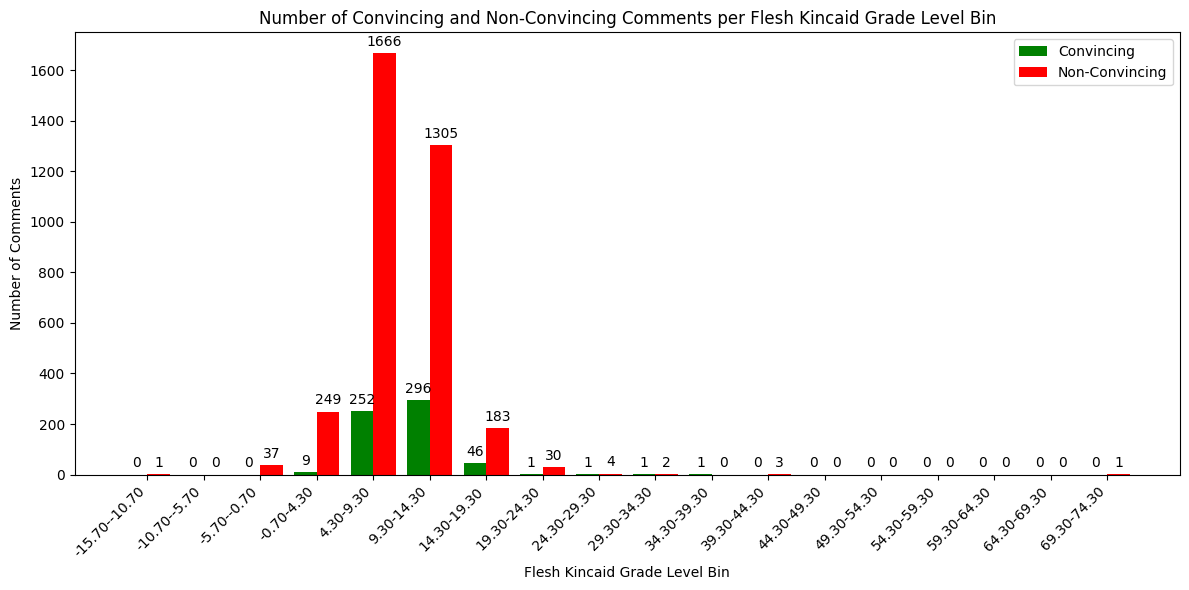

In [ ]:
plot_feature('fk_grade_level_converted', 'Flesh Kincaid Grade Level', 5)

In [ ]:
max_grade_level_row = comments_df.loc[comments_df['fk_grade_level_converted'].idxmax()]
print(f"Example for high FK grade level ({max_grade_level_row['fk_grade_level_converted']}):")
print(max_grade_level_row['final_comment'])
print("-" * 20)


Example for high FK grade level (70.3):
 619   923   799   504   767   802   806   229   757   781
 340   963    79   800   508   656   123   349   282   361
 825   516   597   245   928   713   815   749   913   391
 613   809   320   142   310   684    23    99    36   788
 503   660   140   753     4   144   648   158   889   601
 556   552   814   477   541   530   487   421   356   635
 251   339   186    65    10   906   876   402   642   605
 828   440   478    74   603   405    56   255   750   897
 492   873   355    86   943   467   576    98   403   546
 118   524   509   692   220   197   728   235   604   333
 551   893   846   914   247   658   644   641     6   456
 681   773   223   607   677   820   393    72   593   469
 899     3   289   464   966   238   288   169   386    71
 435     5   241   434   279   737   479   265   281   683
 554   679   269   387   208   133   324   534   353   296
 471   237   176   813   453   129   502   807   177   716
 772   598   636

In [ ]:
comments_df['fk_grade_level'] = comments_df['fk_grade_level_converted']
comments_df.drop(columns=['fk_grade_level_converted'], inplace=True)

### Flesh Kincaid Reading Ease

In [ ]:
comments_df['fk_reading_ease'] = None

In [ ]:
do_calc_feature("fk_reading_ease", lambda text: textstat.flesch_reading_ease(text), remove_urls=True)

In [ ]:
comments_df['fk_reading_ease'].head()

,fk_reading_ease
0,59.9
1,77.23
2,52.02
3,64.51
4,69.79


In [ ]:
comments_df['fk_reading_ease'] = pd.to_numeric(comments_df['fk_reading_ease'], errors='coerce')

In [ ]:
comments_df['fk_reading_ease'].describe()

,fk_reading_ease
count,4088.000000
mean,61.158486
std,19.155757
min,-218.200000
25%,52.430000
50%,61.670000
75%,70.840000
max,206.840000


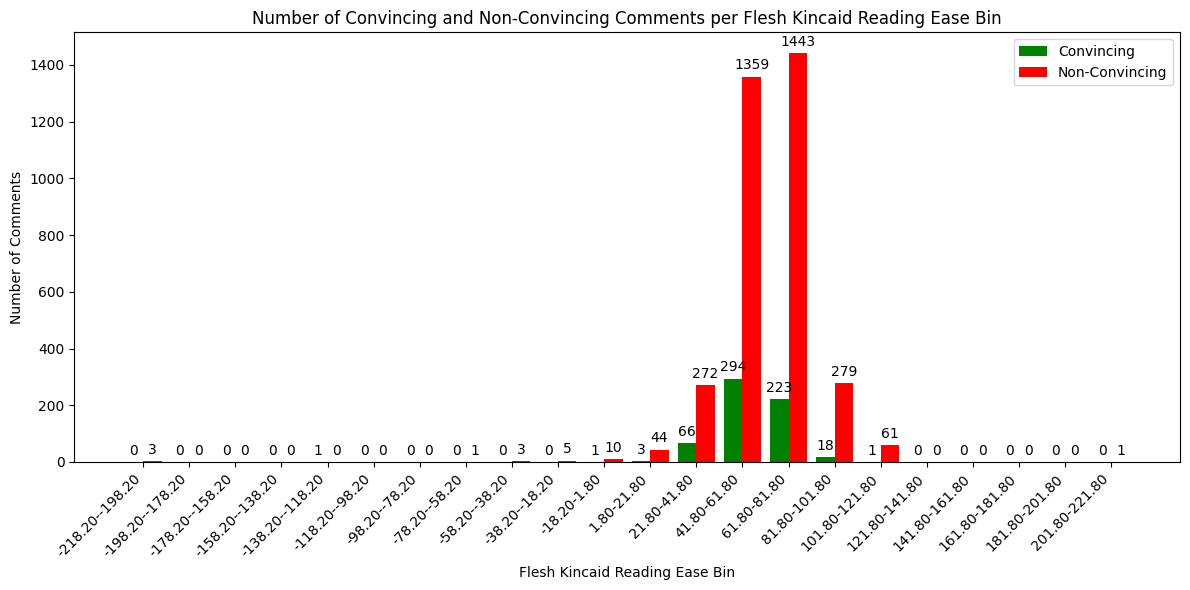

In [ ]:
plot_feature('fk_reading_ease', 'Flesh Kincaid Reading Ease', 20)

In [ ]:
min_row = comments_df.loc[comments_df['fk_reading_ease'].idxmin()]
print(f"Example for very low FK reading ease ({min_row['fk_reading_ease']}):")
print(min_row['final_comment'])
print("-" * 20)


Example for very low FK reading ease (-218.2):
"analyzational"

Analytical?
--------------------


## 6.7 Use of Evidence

The paper, "[Attitude Change on Reddit's Change My View](https://jpriniski.github.io/papers/cogsci-reddit.pdf)," explores how individuals on the Reddit forum **Change My View (CMV)** adjust their beliefs on various topics, particularly focusing on sociomoral issues (e.g., politics, morality) compared to non-sociomoral topics (e.g., humor, fiction).

The studuy includes the code for calculating evidence use in comments. We will adapt the code from their [repo in GitHub](https://github.com/jpriniski/CMV), and execute it on our own dataset, to create the evidence use features.

In [ ]:
extensions = ['http://', 'https://', '.com', '.org', '.gov', 'pdf', '.net', 'www.']

stems = ['data', 'stat', 'statist', 'figur', '%', 'percent', 'averag', 'number', 'amount',
         'thousand', 'million', 'billion', '$', '€', '¥', '£', 'dollar', 'evid', 'info',
         'testimoni', 'conclus', 'document', 'experi', 'experi', 'measur', 'measur', 'report',
         'result', 'census', 'figur', 'plot', 'graph', 'sum', 'total', 'decim', 'digit', 'fraction',
         'numer', 'half', 'share', 'proport', 'capit', 'cash', 'properti', 'salari', 'wage', 'wealth',
         'financ', 'resourc', 'roll', 'treasuri', 'bank', 'deposit', 'exchang', 'safe', 'estim', 'price',
         'price', 'merchandis', 'retail', 'sale', 'cartel', 'invest', 'market', 'deposit', 'document',
         'indic', 'wit', 'affirm', 'corrobor', 'declar', 'good', 'ground', 'token', 'signific', 'probabl',
         'p valu', '<', '=', 'greater', 'equal', 'less', 'rang', 'devi', 'sd', 'mode',
         'median']

import nltk
snow = nltk.stem.SnowballStemmer('english')

def get_evidence_count(text):
    evidence_count = 0
    comment_stemmed = snow.stem(text.lower())

    for word in comment_stemmed.split():
      if any(s == word for s in stems) and not any(e in word for e in extensions):
          evidence_count += 1

    return evidence_count

In [ ]:
comments_df['evidence_count'] = None

In [ ]:
do_calc_feature("evidence_count", get_evidence_count)

In [ ]:
comments_df['evidence_count'].describe()

,evidence_count
count,4088
unique,21
top,0
freq,2602


In [ ]:
comments_df['evidence_count'] = pd.to_numeric(comments_df['evidence_count'])

In [ ]:
comments_df['evidence_count'].describe()

,evidence_count
count,4088.000000
mean,0.849804
std,1.878092
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,31.000000


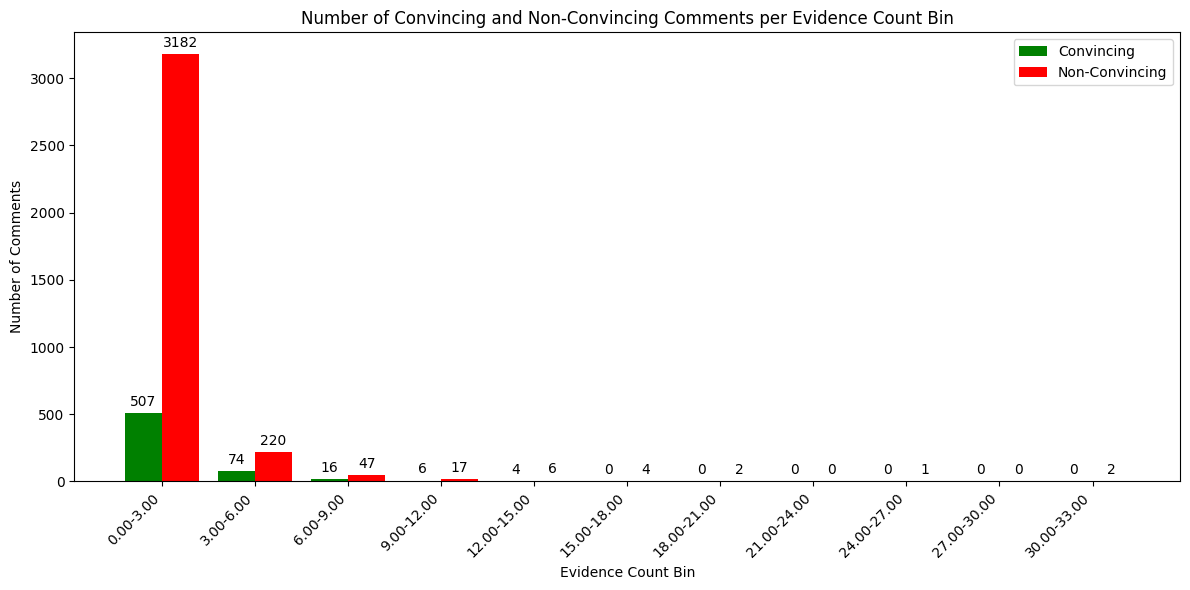

In [ ]:
plot_feature('evidence_count', 'Evidence Count', 3)

In [ ]:
max_row = comments_df.loc[comments_df['evidence_count'].idxmax()]
print(f"Example for high evidence count ({max_row['evidence_count']}):")
print(max_row['thread_text'])
print(max_row['final_comment'])
print("-" * 20)

Example for high evidence count (31):
2. I think it's good to use other countries as a barometer for how much we spend. As a percentage of GDP we spend less than Russia and Saudi Arabia. As a total amount of spending we spend slightly more than Saudi Arabia, Russia, and China combined. The amounts the rest of NATO spends is negligible by comparison. We are spending like 10-20% more than would equal out to all of these countries but that's forgetting that we are fighting very real conflicts around the world. We can reduce our military spending but other NATO countries need to start pulling their own weight before we do.

3. The Military Industrial complex is very important. Part of the reason our economy does well is we're pumping money into it via military spending. The money that goes into making bullets and missiles doesn't evaporate when the they're fired, it goes into the pockets of US defense contractors. When our equipment gets old we sell it off to different countries and get ev

## 6.8 Use of Persuasive Language

We want to identify if the comment and context include use of persuasive language. To do this, we will use a HuggingFace model: https://huggingface.co/chreh/persuasive_language_detector.

From the model card:
> Given a sentence, our model predicts whether or not the sentence contains "persuasive" language, or language designed to elicit emotions or change readers' opinions. The model was tuned on the SemEval 2020 Task 11 dataset. However, we preprocessed the dataset to adapt it from multilabel technique classification and span-classification to our binary classification task.

The model has two flavours, BERT and XLM-RoBERTa. Based on the documentation, the latter performs better and faster, so we will use it.

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
model = AutoModelForSequenceClassification.from_pretrained("chreh/persuasive_language_detector", revision="roberta")


In [ ]:
import torch

max_length = 512
def classify_text(text):
    # The model gets only up to 512 tokens
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=max_length)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    predicted_class = torch.argmax(logits, dim=1).item()

    return predicted_class


In [ ]:
 text = comments_df.iloc[0]['final_comment']
 classify_text(text)

1

In [ ]:
text

'I agree with mercy. But sometimes mercy can rob justice. There comes a time when logic, reasoning, and understanding aren’t enough. The trick is recognizing when a situation like that really comes about. In any case, a man or woman incapable of biting back isn’t really capable of doing a whole lot of good in the world. '

Let's apply the featute on all rows:

In [ ]:
comments_df['use_of_persuasive_lang'] = None

In [ ]:
do_calc_feature("use_of_persuasive_lang", classify_text, switch_order=True)

In [ ]:
comments_df['use_of_persuasive_lang']

,use_of_persuasive_lang
0,1
1,1
2,1
3,1
4,1
...,...
4083,1
4084,0
4085,0
4086,1


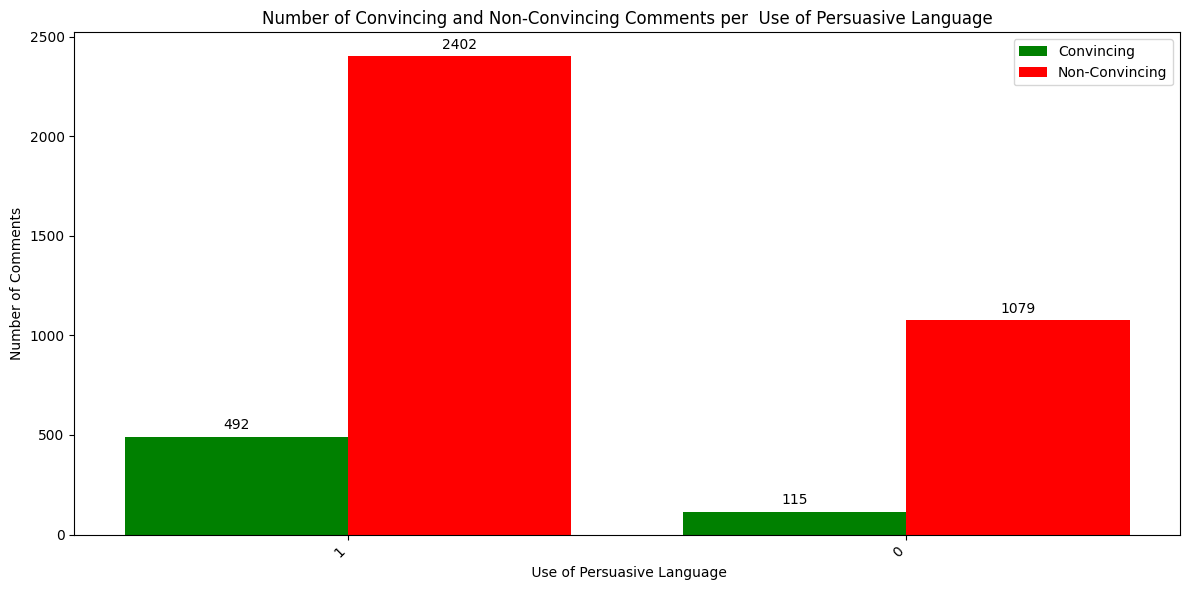

In [ ]:
plot_category_histogram(comments_df, 'use_of_persuasive_lang', ' Use of Persuasive Language')

In [ ]:
# convert comments_df['use_of_persuasive_lang'] to ints
comments_df['use_of_persuasive_lang'] = comments_df['use_of_persuasive_lang'].apply(lambda x: 1 if x == '1' else 0)

## 6.9 Document Embedding

We want that our model will also get some kind of representation of the original text, not only features extracted from it. Therefore we will include the docuemnt embedding in the features list.

First we will calculate the embedding using a variation of the BERT model, bert-base-uncased, which is a well-studied, strong contextual embeddings, suitable for general English NLP tasks.

This model provides encoding of dimension 768.

In [ ]:
import torch
import numpy as np
from transformers import AutoModel, AutoTokenizer

# Load model and tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def get_embedding(text, chunk_size=256, overlap=128):
    """
    Convert a long document into a single embedding using BERT with chunking.

    Parameters:
    - text (str): The long document
    - chunk_size (int): Max tokens per chunk (default: 256)
    - overlap (int): Overlapping tokens between chunks (default: 128)

    Returns:
    - Aggregated document embedding (numpy array of shape [768])
    """
    # Tokenize document without truncation
    tokens = tokenizer(text, return_tensors="pt", truncation=False)["input_ids"][0]

    # Split into chunks with overlap
    chunk_embeddings = []
    for i in range(0, len(tokens), chunk_size - overlap):
        chunk = tokens[i : i + chunk_size]  # Get chunk

        encoded_input = {
            "input_ids": chunk.unsqueeze(0),  # Add batch dimension
            "attention_mask": torch.ones_like(chunk).unsqueeze(0)  # Mask for valid tokens
        }

        # Forward pass through BERT
        with torch.no_grad():
            outputs = model(**encoded_input)

        # Extract last hidden state
        token_embeddings = outputs.last_hidden_state  # Shape: [1, chunk_size, 768]
        chunk_embedding = token_embeddings.mean(dim=1)  # Mean pooling over tokens

        # Store chunk embedding
        chunk_embeddings.append(chunk_embedding.squeeze().numpy())

    # Aggregate all chunk embeddings (mean pooling over chunks)
    document_embedding = np.mean(chunk_embeddings, axis=0)

    return document_embedding

In [ ]:
# Example Usage
long_text = comments_df.iloc[0]['final_comment']
embedding = get_embedding(long_text)
print(embedding.shape)  # Expected output: (768,)

(768,)


In [ ]:
comments_df['embedding'] = None

In [ ]:
do_calc_feature("embedding", get_embedding)

### Embedding Dimension Reduction with PCA
Since the size of the encoding is very big, and adding so many features to our models will not be practical, we will apply PCA on the embeddings.

To decide the PCA dimension, we will execute some statistical computation to understand what is the minimal dimension that will allow us to keep at least 85% of the information that the original embedding contains.

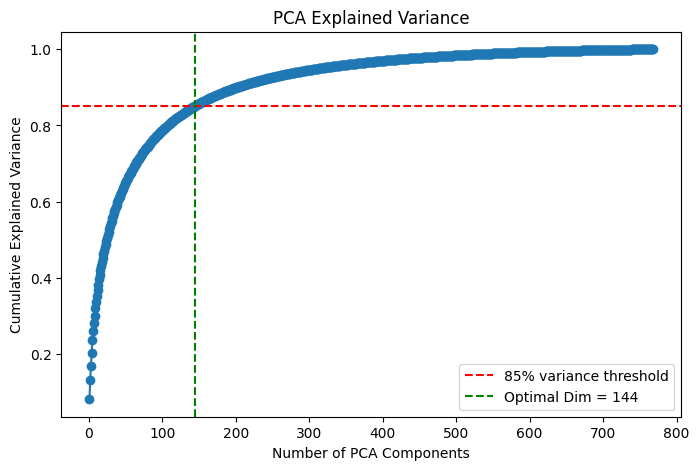

Optimal number of components: 144


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Extract all embeddings into a matrix
embedding_matrix = np.vstack(comments_df["embedding"].values)  # Shape: (num_samples, 768)

# Apply PCA
pca = PCA().fit(embedding_matrix)  # Fit PCA on the full embedding

# Compute cumulative explained variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components that explain at least 85% variance
target_dim = np.argmax(explained_variance >= 0.85) + 1  # +1 because indexing starts at 0

# Plot the explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.axhline(y=0.85, color="r", linestyle="--", label="85% variance threshold")
plt.axvline(x=target_dim, color="g", linestyle="--", label=f"Optimal Dim = {target_dim}")
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.show()

print(f"Optimal number of components: {target_dim}")


Now we will apply the PCA on the embedding:

In [ ]:
pca = PCA(n_components=target_dim)
reduced_embeddings = pca.fit_transform(embedding_matrix)

# Convert back to DataFrame and merge
embedding_columns = [f"embedding_{i}" for i in range(target_dim)]
embedding_df = pd.DataFrame(reduced_embeddings, columns=embedding_columns)

# Merge with original dataset
# comments_df = comments_df.drop(columns=["embedding"]).reset_index(drop=True)
comments_df = pd.concat([comments_df, embedding_df], axis=1)

# ７. The relation between comments and Original Post

We think that it is possible that a correlation between the comments style, tone etc. and the same features for the original post (OP) may be an indicator for the persuasion of a comment.

Therefore, we will create all the features also for the OP, and include them too as input for the model.

Since many of our commnets share the same original post, we will temporarily create a dataframe with the unique OPs. We will calculate the features for these unique values (to save time), and then we will copy these values into the original dataframe.

In [ ]:
op_df = comments_df['original_post'].drop_duplicates()
op_df.reset_index(drop=True, inplace=True)
op_df = pd.DataFrame(op_df)
op_df

,original_post
0,"CMV: Instead of teaching youth to ""not judge"" ..."
1,CMV: Single toilet restrooms in restaurants th...
2,CMV: If Donald Trump's comments and social med...
3,"CMV: The universe indifferent to suffering, go..."
4,CMV: Safe spaces are unhealthy because college...
...,...
395,CMV: People that want to become elected offici...
396,CMV: You shouldn't be able to see how many upv...
397,CMV: White people can wear cornrows\nWhen my s...
398,CMV: Drugs shouldn't be criminalized unless yo...


## 7.1 Sentiment Analysis

In [ ]:
op_df["sentiment_op"] = op_df['original_post'].apply(get_sentiment)

op_df.describe()

,sentiment_op
count,400.000000
mean,0.230900
std,0.813966
min,-0.999800
25%,-0.772375
50%,0.725250
75%,0.967500
max,0.999600


## 7.2 Tone

In [ ]:
op_df['tone_google_op'] = None

def get_tone_from_google_ai(row):
  text = row['original_post']
  user_prompt = user_prompt_prefix + text
  response = llm_gemini.invoke(user_prompt)
  classification = response.content.strip()
  print(f"row {row.name} classified as {classification}")
  return classification

In [ ]:
import time

counter = 0
# this loop can be executed multiple times until all entries were classified
for index, row in op_df.iterrows():
  if counter == 5:
    time.sleep(3)  # add some sleep so we don't get out of quota
    counter = 0
  if pd.isna(row['tone_google_op']):  # calculate only if wasn't calculated yet
      op_df.at[index, 'tone_google_op'] = get_tone_from_google_ai(row)
      counter += 1

## 7.3 Style

In [ ]:
import re
def do_calc_feature_op(feature, func, remove_urls=False):
  for index, row in op_df.iterrows():
    if pd.isna(row[feature]):  # calculate only if wasn't calculated yet
      print(f"Calculating {feature} for index {index}")
      text = row['original_post']

      if remove_urls:
        text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
      op_df.at[index, feature] = func(text)

In [ ]:
op_df['style_op'] = None

In [ ]:
do_calc_feature_op("style_op", get_style)

In [ ]:
op_df['style_label_op'] = op_df['style_op'].apply(get_style_label)

## 7.4 Adjective-Adverb Ratio

In [ ]:
op_df['adj_adv_ratio_op'] = None

In [ ]:
do_calc_feature_op("adj_adv_ratio_op", get_adjective_adverb_ratio)

In [ ]:
op_df['adj_adv_ratio_op'].describe()

,adj_adv_ratio_op
count,400.000000
mean,inf
std,NaN
min,0.333333
25%,1.124238
50%,1.433036
75%,1.875000
max,inf


In [ ]:
op_df['adj_adv_ratio_op'].replace(np.inf, 0).describe()

,adj_adv_ratio_op
count,400.000000
mean,1.595115
std,0.729548
min,0.000000
25%,1.121463
50%,1.428571
75%,1.870924
max,5.250000


In [ ]:
op_df['adj_adv_ratio_op'] = op_df['adj_adv_ratio_op'].replace(np.inf, 7)

## 7.5 Readability - Grade Level

In [ ]:
op_df['fk_grade_level_op'] = None

import textstat
do_calc_feature_op("fk_grade_level_op", lambda text: textstat.flesch_kincaid_grade(text), remove_urls=True)

## 7.6 Readability - Reading Ease

In [ ]:
op_df['fk_reading_ease_op'] = None

do_calc_feature_op("fk_reading_ease_op", lambda text: textstat.flesch_reading_ease(text), remove_urls=True)

## 7.7 Evidence Use

In [ ]:
op_df['evidence_count_op'] = None

do_calc_feature_op("evidence_count_op", get_evidence_count)

## 7.8 Combine op_df into comments_df

In [ ]:
for index, row in comments_df.iterrows():
    # Find matching original_post in op_df
    matching_rows = op_df[op_df['original_post'] == row['original_post']]

    if matching_rows.empty:
      continue

    # Copy columns from op_df to comments_df
    for col in op_df.columns:
      if col != 'original_post':  # Skip the original_post column itself
        comments_df.loc[index, col] = matching_rows[col].iloc[0]


In [ ]:
comments_df.head()

,original_post,thread_text,final_comment,is_convincing,final_comment_id,cleaned_final_comment,cleaned_thread_text,cleaned_original_post,sentiment,tone,...,embedding_143,embedding_converted,sentiment_op,tone_google_op,style_op,adj_adv_ratio_op,fk_grade_level_op,fk_reading_ease_op,evidence_count_op,style_label_op
0,"CMV: Instead of teaching youth to ""not judge"" ...",NaN,I agree with mercy. But sometimes mercy can ro...,0,dtni266,agree with mercy But sometimes mercy can rob ...,NaN,CMV Instead of teaching youth to not judge we ...,0.9134,"[{'label': 'neutral', 'score': 0.8615567088127...",...,0.032372,"[-0.151773781, 0.160338879, 0.018658299, -0.02...",-0.9313,Logical,{'sequence': 'CMV: Instead of teaching youth t...,1.791667,11.7,60.28,2.0,formal
1,"CMV: Instead of teaching youth to ""not judge"" ...",NaN,I’m also an early childhood educator and came ...,0,dtnii0t,Im also an early childhood educator and came h...,NaN,CMV Instead of teaching youth to not judge we ...,-0.8415,"[{'label': 'anger', 'score': 0.8864083886146545}]",...,0.187012,"[0.0420717113, 0.287623823, 0.171164721, 0.017...",-0.9313,Logical,{'sequence': 'CMV: Instead of teaching youth t...,1.791667,11.7,60.28,2.0,formal
2,"CMV: Instead of teaching youth to ""not judge"" ...",I am not trying to change your view because it...,I would try to use the most Neutral vocabulary...,0,dtr7sbi,would try to use the most Neutral vocabulary ...,am not trying to change your view because it ...,CMV Instead of teaching youth to not judge we ...,0.9817,"[{'label': 'neutral', 'score': 0.6452071666717...",...,-0.027630,"[-0.0811420381, 0.27216652, 0.0728575587, -0.0...",-0.9313,Logical,{'sequence': 'CMV: Instead of teaching youth t...,1.791667,11.7,60.28,2.0,formal
3,"CMV: Instead of teaching youth to ""not judge"" ...",What do you mean by having your self-esteem wr...,"And thank you, surprisingly kind and reasonabl...",0,dtvacj0,And thank you surprisingly kind and reasonable...,What do you mean by having your selfesteem wre...,CMV Instead of teaching youth to not judge we ...,-0.9973,"[{'label': 'fear', 'score': 0.5824066400527954}]",...,0.129848,"[-0.0792442188, 0.307334602, 0.0667393357, -0....",-0.9313,Logical,{'sequence': 'CMV: Instead of teaching youth t...,1.791667,11.7,60.28,2.0,formal
4,"CMV: Instead of teaching youth to ""not judge"" ...",The human brain is explicitly evolved to judge...,"Agreed... this is how we live, how our species...",0,dtrsop3,Agreed this is how we live how our species has...,The human brain is explicitly evolved to judge...,CMV Instead of teaching youth to not judge we ...,0.5859,"[{'label': 'neutral', 'score': 0.8495560884475...",...,-0.033363,"[0.27266106, 0.185307801, 0.104097173, -0.1035...",-0.9313,Logical,{'sequence': 'CMV: Instead of teaching youth t...,1.791667,11.7,60.28,2.0,formal


Let's save the final dataframe.

In [ ]:
file_path = '/content/drive/MyDrive/cmv_comments_df.csv'
comments_df.to_csv(file_path, index=False) # Set index=False to avoid saving row indices

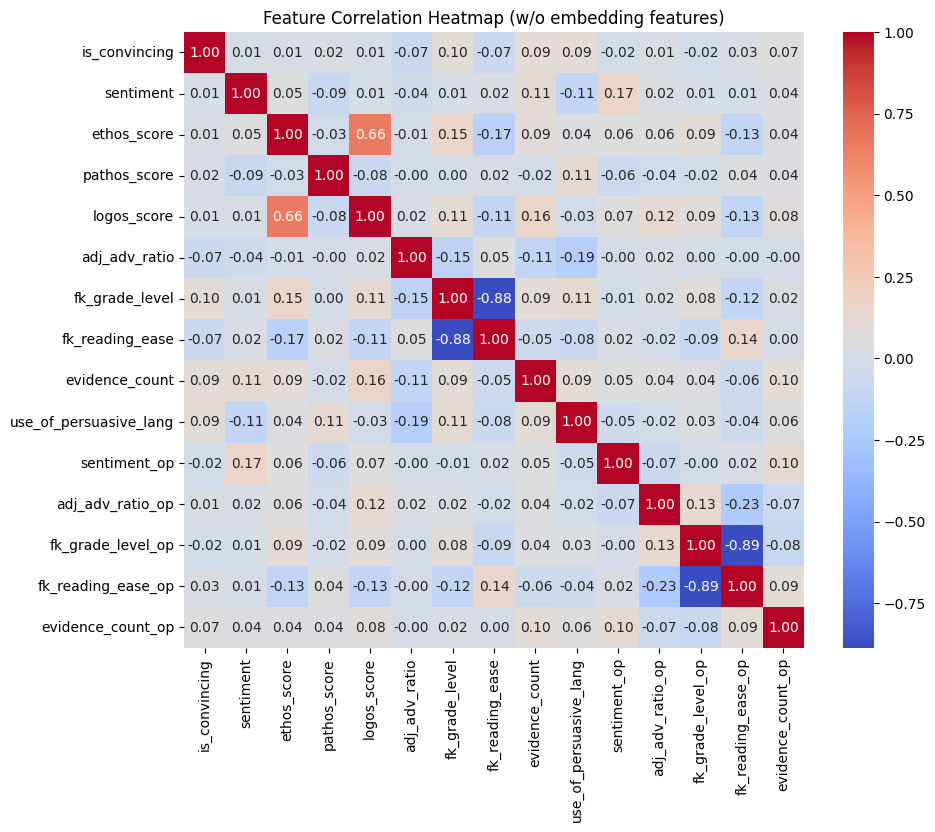

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation for numeric features only
comments_df_no_embedding = comments_df.loc[:, ~comments_df.columns.str.startswith('embedding_')]
corr_matrix = comments_df_no_embedding.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap (w/o embedding features)")
plt.show()

# ８. Training a Model to Predict Persuasiveness

The final step would be to use all the features we created as input to multiple ML models to predict whether a comment would be convincing. We will train multiple models and search for the best model.

In [ ]:
comments_df.columns

Index(['original_post', 'thread_text', 'final_comment', 'is_convincing',
       'final_comment_id', 'cleaned_final_comment', 'cleaned_thread_text',
       'cleaned_original_post', 'sentiment', 'tone', 'tone_label',
       'tone_google', 'style', 'ethos_score', 'pathos_score', 'logos_score',
       'adj_adv_ratio', 'fk_grade_level', 'fk_reading_ease', 'style_label',
       'evidence_count', 'sentiment_op', 'tone_google_op', 'style_op',
       'adj_adv_ratio_op', 'fk_grade_level_op', 'fk_reading_ease_op',
       'evidence_count_op', 'style_label_op'],
      dtype='object')

In [ ]:
categorical_features = ["tone_google", 'tone_google_op']
binary_features = ["style_label", 'style_label_op']
numeric_features = ["sentiment", "adj_adv_ratio", 'fk_grade_level', 'fk_reading_ease', 'evidence_count',
                    'sentiment_op', 'adj_adv_ratio_op', 'fk_grade_level_op', 'fk_reading_ease_op', 'evidence_count_op']
label = "is_convincing"

## 8.1 Encode Categorical Features

In [ ]:
comments_df['is_formal'] = comments_df['style_label'].apply(lambda x: 1 if x == 'formal' else 0)
comments_df['is_formal_op'] = comments_df['style_label_op'].apply(lambda x: 1 if x == 'formal' else 0)

In [ ]:
comments_df[['style_label', 'is_formal', 'style_label_op', 'is_formal_op']].head()


,style_label,is_formal,style_label_op,is_formal_op
0,formal,1,formal,1
1,informal,0,formal,1
2,informal,0,formal,1
3,informal,0,formal,1
4,formal,1,formal,1


In [ ]:
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(sparse_output=False, drop='first')
tone_encoded = onehot_encoder.fit_transform(comments_df[categorical_features])
tone_df = pd.DataFrame(tone_encoded, columns=onehot_encoder.get_feature_names_out())

comments_df = comments_df.drop(columns=categorical_features).reset_index(drop=True)
comments_df = pd.concat([comments_df, tone_df], axis=1)

In [ ]:
tone_df.columns


Index(['tone_google_Challenging', 'tone_google_Compassionate',
       'tone_google_Concerned', 'tone_google_Curious',
       'tone_google_Frustrated', 'tone_google_Hopeful', 'tone_google_Humorous',
       'tone_google_Logical', 'tone_google_Neutral', 'tone_google_Nostalgic',
       'tone_google_Observational', 'tone_google_Optimistic',
       'tone_google_Other', 'tone_google_Passionate', 'tone_google_Reassuring',
       'tone_google_Sarcastic', 'tone_google_Skeptical', 'tone_google_nan',
       'tone_google_op_Humorous', 'tone_google_op_Logical',
       'tone_google_op_Neutral', 'tone_google_op_Passionate',
       'tone_google_op_Sarcastic'],
      dtype='object')

## 8.2 Split to Train and Test

First, we want to create a final dataframe with only the relevant features

In [ ]:
features = tone_df.columns.tolist() + ['is_formal', 'is_formal_op'] + numeric_features + [label]
data = comments_df[features]
data.head()

,tone_google_Challenging,tone_google_Compassionate,tone_google_Concerned,tone_google_Curious,tone_google_Frustrated,tone_google_Hopeful,tone_google_Humorous,tone_google_Logical,tone_google_Neutral,tone_google_Nostalgic,...,adj_adv_ratio,fk_grade_level,fk_reading_ease,evidence_count,sentiment_op,adj_adv_ratio_op,fk_grade_level_op,fk_reading_ease_op,evidence_count_op,is_convincing
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.750000,7.7,59.90,1,-0.9313,1.791667,11.7,60.28,2.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.571429,5.2,77.23,0,-0.9313,1.791667,11.7,60.28,2.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.142857,12.8,52.02,2,-0.9313,1.791667,11.7,60.28,2.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.313725,8.0,64.51,5,-0.9313,1.791667,11.7,60.28,2.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,2.000000,6.0,69.79,1,-0.9313,1.791667,11.7,60.28,2.0,0


In [ ]:
data.columns

Index(['tone_google_Challenging', 'tone_google_Compassionate',
       'tone_google_Concerned', 'tone_google_Curious',
       'tone_google_Frustrated', 'tone_google_Hopeful', 'tone_google_Humorous',
       'tone_google_Logical', 'tone_google_Neutral', 'tone_google_Nostalgic',
       'tone_google_Observational', 'tone_google_Optimistic',
       'tone_google_Other', 'tone_google_Passionate', 'tone_google_Reassuring',
       'tone_google_Sarcastic', 'tone_google_Skeptical', 'tone_google_nan',
       'tone_google_op_Humorous', 'tone_google_op_Logical',
       'tone_google_op_Neutral', 'tone_google_op_Passionate',
       'tone_google_op_Sarcastic', 'is_formal', 'is_formal_op', 'sentiment',
       'adj_adv_ratio', 'fk_grade_level', 'fk_reading_ease', 'evidence_count',
       'sentiment_op', 'adj_adv_ratio_op', 'fk_grade_level_op',
       'fk_reading_ease_op', 'evidence_count_op', 'is_convincing'],
      dtype='object')

In [ ]:
import plotly.express as px

labels=["Convincing","Not Convincing"]

convincing = data["is_convincing"].value_counts().tolist()
values = [convincing[0], convincing[1]]

fig = px.pie(values=data["is_convincing"].value_counts(), names=labels , width=700, height=400, color_discrete_sequence=['skyblue', 'orange']
             ,title="Convincing Vs. Not-Convincing Comments")
fig.show()

In [ ]:
data["is_convincing"].value_counts()

,count
is_convincing,
0,3481
1,607


In [ ]:
# Sepratating & assigning features and target columns to X & y
y = data["is_convincing"]
X = data.drop('is_convincing',axis=1)
X.shape, y.shape

((4088, 35), (4088,))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y,test_size = 0.2, random_state = 42)

X_train.shape, X_test.shape

((3270, 35), (818, 35))

In [ ]:
import pandas as pd
# Combine X_train and y_train
combined_df = pd.concat([X_train, y_train], axis=1)

# Save to file
file_path = '/content/drive/MyDrive/combined_train_data.csv'
combined_df.to_csv(file_path, index=False)


combined_df = pd.concat([X_test, y_test], axis=1)

# Save to file
file_path = '/content/drive/MyDrive/combined_test_data.csv'
combined_df.to_csv(file_path, index=False)

## 8.3 Scale Data

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled_features = scaler.fit_transform(X_train[numeric_features])
X_test_scaled_features = scaler.transform(X_test[numeric_features])

X_train[numeric_features] = X_train_scaled_features
X_test[numeric_features] = X_test_scaled_features

## 8.4 Train and Evaluate Models - Version 1

Important: The following training of the models was executed on a previous version of the data, that did not include the feature 'use_of_presuasive_lang' and the embeddings.

In a later phase we added the additional features. Below (section 8.5) we include re-training of the models with the new features.

In [ ]:
pip install xgboost

In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display, Markdown
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

In [ ]:
import random
np.random.seed(402) # we would like to set the random seed, to be able to reproduce the results, because we use Random Forest model.
scoring='f1'

models = [
    ('logistic regression', GridSearchCV(
        LogisticRegression(random_state=42, class_weight='balanced'),
         {'C': [0.1, 1, 10, 100],
          'penalty': ['l1', 'l2'],
          'solver': ['lbfgs', 'newton-cholesky', 'liblinear']},
        cv=5, scoring=scoring)),

    ('SVC', GridSearchCV(
        SVC(random_state=42, class_weight='balanced'),
         {'C': [0.1, 1, 10],
          'kernel': ['linear', 'rbf'],
          'gamma': [0.1, 1, 10],
          'degree': [2, 3, 4]},
        cv= 5, scoring=scoring)),

    ('decision tree', GridSearchCV(
        DecisionTreeClassifier(random_state=42, class_weight='balanced'),
         {'max_depth': [None, 5, 10, 15],
          'min_samples_split': [2, 5, 10],
          'min_samples_leaf': [1, 5, 20],
          'max_features': [None, 'sqrt', 'log2']},
        cv= 5, scoring=scoring)),

    ('random forest', GridSearchCV(
        RandomForestClassifier(random_state=42, class_weight='balanced'),
         {'n_estimators': [10, 100, 1000],
          'max_depth': [None, 5, 10, 15],
          'min_samples_split': [2, 5, 10],
          'min_samples_leaf': [1, 5, 20]},
        cv=5, scoring=scoring)),

    ('xgboost', GridSearchCV(
        xgb.XGBClassifier(random_state=42, scale_pos_weight=1),  # scale_pos_weight can be used for imbalance
        {'n_estimators': [50, 100, 200],
         'learning_rate': [0.01, 0.1, 0.3],
         'max_depth': [3, 6, 9],
         'gamma': [0, 0.1, 0.2]},
        cv=5, scoring=scoring))
    ]

In [ ]:
threshold = 0.5 # Convert probabilities to binary predictions (0 or 1)

def measure_error(y_true, y_pred_proba, label):
    y_pred = (y_pred_proba >= threshold).astype(int)
    return pd.Series({"accuracy": accuracy_score(y_true, y_pred),
                      'recall': recall_score(y_true, y_pred, average ='macro'),
                      'f1': f1_score(y_true, y_pred, average ='macro')},
                      name=label)

def execute_models(X_train, y_train, X_test, y_test, models):
  metrics = list()
  for model_name, model in models:
      print(f"Training {model_name}...")

      model.fit(X_train, y_train)
      if hasattr(model, "predict_proba"):
        y_test_positive_pred = model.predict_proba(X_test)[:,1]
        y_train_positive_pred = model.predict_proba(X_train)[:,1]

      elif hasattr(model, "decision_function"):  # Use decision_function for SVC
            y_test_positive_pred = model.decision_function(X_test)
            y_train_positive_pred = model.decision_function(X_train)
      else:
            raise ValueError(f"Model {model_name} does not support probability prediction.")

      # Evaluate
      print(f"Evaluating {model_name} ...")
      train_test_full_error = pd.concat([measure_error(y_test, y_test_positive_pred, 'test '+ model_name),
                                        measure_error(y_train, y_train_positive_pred, 'train '+ model_name)],
                                        axis=1)
      metrics.append(train_test_full_error)

  metrics = pd.concat(metrics, axis=1)
  return metrics

In [ ]:
metrics = execute_models(X_train, y_train, X_test, y_test, models)

In [ ]:
display(Markdown('**ML models**'))
display(metrics)

**ML models**

,test logistic regression,train logistic regression,test SVC,train SVC,test decision tree,train decision tree,test random forest,train random forest,test xgboost,train xgboost
accuracy,0.556235,0.588991,0.770171,0.819878,0.733496,0.817431,0.804401,0.893578,0.870416,0.962385
recall,0.623493,0.646525,0.626095,0.783820,0.659212,0.829939,0.673500,0.884849,0.616621,0.875155
f1,0.496861,0.522782,0.606026,0.717423,0.605450,0.731624,0.653320,0.821955,0.648420,0.917087


### Initial training results
* Best Accuracy: XGBoost - 0.870416
* Best recall: Random Forest - 0.673500
* Best F1: Random Forest - 0.653320

The results seem not good enough, so we will try to use undersampling to solve the imbalanced data issue that may affect the models ability to predict correctly.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(
    sampling_strategy='auto',
    random_state=42
)
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

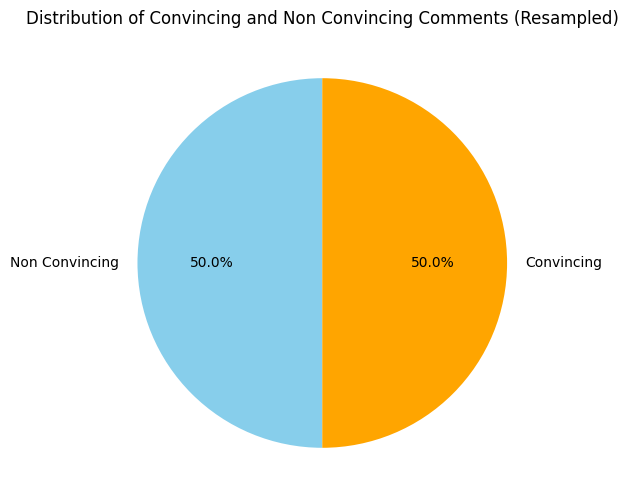

In [ ]:
class_distribution = pd.Series(y_train_resampled).value_counts()

# Labels and sizes for the pie chart
labels = ['Non Convincing', 'Convincing']
sizes = class_distribution.values

# Plot the pie chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'orange'])
plt.title('Distribution of Convincing and Non Convincing Comments (Resampled)')
plt.show()

In [ ]:
metrics = execute_models(X_train_resampled, y_train_resampled, X_test, y_test, models)

In [ ]:
display(Markdown('**ML models - Balanced Data**'))
display(metrics)

**ML models - Balanced Data**

,test logistic regression,train logistic regression,test SVC,train SVC,test decision tree,train decision tree,test random forest,train random forest,test xgboost,train xgboost
accuracy,0.536675,0.637860,0.694377,0.765432,0.597800,0.723251,0.638142,0.897119,0.668704,0.997942
recall,0.642749,0.637860,0.629427,0.765432,0.671787,0.723251,0.698875,0.897119,0.696320,0.997942
f1,0.490192,0.632443,0.571530,0.764411,0.534812,0.721411,0.566778,0.896945,0.584065,0.997942


### Training with Undersampling Results
* Best Accuracy: SVC - 0.694377
* Best recall: Random Forest - 0.698875
* Best F1: XGBoost - 0.584065

### Previous Results
* Best Accuracy: XGBoost - 0.870416
* Best recall: Random Forest - 0.673500
* Best F1: Random Forest - 0.653320

### Best Results So Far
* Best Accuracy: XGBoost (initial training) - 0.870416
* Best recall: Random Forest (Undersampling) - 0.698875
* Best F1: Random Forest (initial training) - 0.653320

We will try to balance the dataset with Oversampling instead - it means to create synthetic data for the minority class (convincing comments).

In [ ]:
from imblearn.over_sampling import SMOTE

oversample_strategy = 'auto'

smote = SMOTE(sampling_strategy=oversample_strategy, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

Make sure that we have the same amount of comments in both classes:

In [ ]:
y_train_resampled.value_counts()

,count
is_convincing,
1,2784
0,2784


Finally let's re-run the models

In [ ]:
metrics = execute_models(X_train_resampled, y_train_resampled, X_test, y_test, models)

In [ ]:
display(Markdown('**ML models - After Oversampling**'))
display(metrics)

**ML models - After Oversampling**

,test logistic regression,train logistic regression,test SVC,train SVC,test decision tree,train decision tree,test random forest,train random forest,test xgboost,train xgboost
accuracy,0.850856,0.667744,0.852078,0.999641,0.628362,0.99982,0.847188,0.99982,0.826406,0.99982
recall,0.499283,0.667744,0.500000,0.999641,0.450680,0.99982,0.500545,0.99982,0.495180,0.99982
f1,0.459709,0.667029,0.460066,0.999641,0.449802,0.99982,0.466456,0.99982,0.472555,0.99982


### Training with Oversampling Results
* Best Accuracy: SVC - 0.852078
* Best recall: Random Forest - 0.500545
* Best F1: XGBoost - 0.472555

### Previous Results
* Best Accuracy: XGBoost (initial training) - 0.870416
* Best recall: Random Forest (Undersampling) - 0.698875
* Best F1: Random Forest (initial training) - 0.653320

### Best Results So Far
* Best Accuracy: XGBoost (initial training) - 0.870416
* Best recall: Random Forest (Undersampling) - 0.698875
* Best F1: Random Forest (initial training) - 0.653320


Oversampling did not improve any of the metrics.

## 8.5 Train and Evaluate Models - Version 2

Due to low performance, we added to our dataset new features. The first is the 'use_of_persuasive_lang' and the second is actually a set of features, which are the embedding features, see sections 6.8 and 6.9 above for documentation.

We will re-define the columns and execute all pre-processing like done for the first version of training.

In [ ]:
chunk_size = 10
cols = list(comments_df.columns)
for i in range(0, len(cols), chunk_size):
    print(str(cols[i:i + chunk_size]).strip('[]'))

'original_post', 'thread_text', 'final_comment', 'is_convincing', 'final_comment_id', 'cleaned_final_comment', 'cleaned_thread_text', 'cleaned_original_post', 'sentiment', 'tone'
'tone_label', 'tone_google', 'style', 'ethos_score', 'pathos_score', 'logos_score', 'adj_adv_ratio', 'fk_grade_level', 'fk_reading_ease', 'style_label'
'evidence_count', 'use_of_persuasive_lang', 'embedding', 'embedding_0', 'embedding_1', 'embedding_2', 'embedding_3', 'embedding_4', 'embedding_5', 'embedding_6'
'embedding_7', 'embedding_8', 'embedding_9', 'embedding_10', 'embedding_11', 'embedding_12', 'embedding_13', 'embedding_14', 'embedding_15', 'embedding_16'
'embedding_17', 'embedding_18', 'embedding_19', 'embedding_20', 'embedding_21', 'embedding_22', 'embedding_23', 'embedding_24', 'embedding_25', 'embedding_26'
'embedding_27', 'embedding_28', 'embedding_29', 'embedding_30', 'embedding_31', 'embedding_32', 'embedding_33', 'embedding_34', 'embedding_35', 'embedding_36'
'embedding_37', 'embedding_38', 'e

In [ ]:
categorical_features = ["tone_google", 'tone_google_op']
binary_features = ["style_label", 'style_label_op', 'use_of_persuasive_lang']
numeric_features = ["sentiment", "adj_adv_ratio", 'fk_grade_level', 'fk_reading_ease', 'evidence_count',
                    'sentiment_op', 'adj_adv_ratio_op', 'fk_grade_level_op', 'fk_reading_ease_op', 'evidence_count_op']
embedding_columns = [f'embedding_{i}' for i in range(143)]
label = "is_convincing"

Encode the categorical features:

In [ ]:
comments_df['is_formal'] = comments_df['style_label'].apply(lambda x: 1 if x == 'formal' else 0)
comments_df['is_formal_op'] = comments_df['style_label_op'].apply(lambda x: 1 if x == 'formal' else 0)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(sparse_output=False, drop='first')
tone_encoded = onehot_encoder.fit_transform(comments_df[categorical_features])
tone_df = pd.DataFrame(tone_encoded, columns=onehot_encoder.get_feature_names_out())

comments_df = comments_df.drop(columns=categorical_features).reset_index(drop=True)
comments_df = pd.concat([comments_df, tone_df], axis=1)

Split to train and test:

In [ ]:
features = tone_df.columns.tolist() + ['is_formal', 'is_formal_op', 'use_of_persuasive_lang'] + numeric_features + embedding_columns + [label]
data = comments_df[features]

y = data["is_convincing"]
X = data.drop('is_convincing',axis=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y,test_size = 0.2, random_state = 42)

In [ ]:
import pandas as pd
# Combine X_train and y_train
combined_df = pd.concat([X_train, y_train], axis=1)

# Save to file
file_path = '/content/drive/MyDrive/combined_train_data.csv'
combined_df.to_csv(file_path, index=False)


combined_df = pd.concat([X_test, y_test], axis=1)

# Save to file
file_path = '/content/drive/MyDrive/combined_test_data.csv'
combined_df.to_csv(file_path, index=False)

Scale the numeric features:

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled_features = scaler.fit_transform(X_train[numeric_features])
X_test_scaled_features = scaler.transform(X_test[numeric_features])

X_train[numeric_features] = X_train_scaled_features
X_test[numeric_features] = X_test_scaled_features

### Feature Selection
Including the embedding in the features list dramatically increases the number of features, so we will apply feature selection using the RFE - Recursive Feature Elimination technique.


We will try with 100 features.

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Feature selection using RFE (Recursive Feature Elimination)
number_of_features = 100
selector = RFE(estimator=RandomForestClassifier(), n_features_to_select=number_of_features)
X_train_selected = selector.fit_transform(X_train, y_train)

In [ ]:
selector.get_feature_names_out()

array(['tone_google_Logical', 'sentiment', 'fk_grade_level',
       'fk_reading_ease', 'sentiment_op', 'adj_adv_ratio_op',
       'fk_grade_level_op', 'fk_reading_ease_op', 'evidence_count_op',
       'embedding_0', 'embedding_1', 'embedding_2', 'embedding_3',
       'embedding_4', 'embedding_5', 'embedding_6', 'embedding_7',
       'embedding_9', 'embedding_10', 'embedding_11', 'embedding_12',
       'embedding_14', 'embedding_16', 'embedding_17', 'embedding_18',
       'embedding_19', 'embedding_20', 'embedding_21', 'embedding_22',
       'embedding_23', 'embedding_24', 'embedding_25', 'embedding_26',
       'embedding_27', 'embedding_28', 'embedding_29', 'embedding_30',
       'embedding_33', 'embedding_34', 'embedding_35', 'embedding_36',
       'embedding_37', 'embedding_38', 'embedding_39', 'embedding_40',
       'embedding_41', 'embedding_42', 'embedding_44', 'embedding_45',
       'embedding_48', 'embedding_51', 'embedding_52', 'embedding_53',
       'embedding_55', 'embedding_

In [ ]:
print(list(selector.get_feature_names_out()))

['tone_google_Logical', 'sentiment', 'fk_grade_level', 'fk_reading_ease', 'sentiment_op', 'adj_adv_ratio_op', 'fk_grade_level_op', 'fk_reading_ease_op', 'evidence_count_op', 'embedding_0', 'embedding_1', 'embedding_2', 'embedding_3', 'embedding_4', 'embedding_5', 'embedding_6', 'embedding_7', 'embedding_9', 'embedding_10', 'embedding_11', 'embedding_12', 'embedding_14', 'embedding_16', 'embedding_17', 'embedding_18', 'embedding_19', 'embedding_20', 'embedding_21', 'embedding_22', 'embedding_23', 'embedding_24', 'embedding_25', 'embedding_26', 'embedding_27', 'embedding_28', 'embedding_29', 'embedding_30', 'embedding_33', 'embedding_34', 'embedding_35', 'embedding_36', 'embedding_37', 'embedding_38', 'embedding_39', 'embedding_40', 'embedding_41', 'embedding_42', 'embedding_44', 'embedding_45', 'embedding_48', 'embedding_51', 'embedding_52', 'embedding_53', 'embedding_55', 'embedding_57', 'embedding_59', 'embedding_62', 'embedding_63', 'embedding_64', 'embedding_66', 'embedding_67', 'em

In [ ]:
X_train_selected.shape

(3270, 100)

Finally we can train the models.

In [ ]:
X_test_selected = selector.transform(X_test)

In [ ]:
metrics = execute_models(X_train_selected, y_train, X_test_selected, y_test, models)

In [ ]:
display(Markdown('**ML models - Selected Features**'))
display(metrics)

**ML models - Selected Features**

,test logistic regression,train logistic regression,test SVC,train SVC,test decision tree,train decision tree,test random forest,train random forest,test xgboost,train xgboost
accuracy,0.669927,0.699388,0.858191,0.982875,0.628362,0.716514,0.733496,0.801529,0.869193,1.0
recall,0.686792,0.714757,0.606033,0.986546,0.621424,0.757084,0.652383,0.807862,0.612489,1.0
f1,0.581505,0.609184,0.630729,0.967477,0.535338,0.634225,0.602154,0.711456,0.643221,1.0


### Training with Embedding + Feature Selection Results
* Best Accuracy: XGBoost - 0.869193
* Best recall: Logistic Regression - 0.686792
* Best F1: XGBoost - 0.643221

### Previous Results
* Best Accuracy: XGBoost (initial training) - 0.870416
* Best recall: Random Forest (Undersampling) - 0.698875
* Best F1: Random Forest (initial training) - 0.653320


### Best Results
* Best Accuracy: XGBoost (initial training) - 0.870416
* Best recall: Random Forest (Undersampling) - 0.698875
* Best F1: Random Forest (initial training) - 0.653320


As we see, adding the embedding and using feture selection did not improve the results.

# ９. Conclusion and Future Research

In this work we investigated comments from the CMV forum.


We created a new and rich dataset with comments, context (thread text by the author of the comment), original post and several features extracted from the comment + context text and from the original post text.


This dataset can be extended in the future by adding more features and can be used for furher studies.


Possible features to add (we didn't add them due to time limitations):
* Lexical Complexity:
  * Type-token ratio (TTR) – Measures vocabulary richness.
  * Word frequency analysis – Uses external corpora to determine whether a text contains rare or common words.
* Syntactic Complexity:
  * Parse tree depth – Longer, more nested sentences are syntactically complex.
  * Mean length of sentences (MLS) – Longer sentences generally indicate higher complexity.


The dataset can be downloded from [here](https://drive.google.com/file/d/1cJWCp6StLol6M9yQHdI6irssBkTi-dKO/view?usp=sharing).

Once we had the dataset, we trained multiple ML models and checked their ability to predict persuasiveness.

We saw that although participants in the CMV forum post their opinions with the intention of hearing opposing views and being open to persuasion, in practice, there is a relatively small number of messages that are marked as persuasive by those same writers. This leads to an imbalanced dataset, which can be a challenge for ML models. We tried 2 resampling methods to overcome this problem.

We also tried to add embedding of the original text and include this in the features. Since this adds a lot of features, we combined this change with Feature Selection technique. We chose to use 100 features, but of course, future researches can try different numbers of features to get improved results.

The best results we got from this research were:
* Best Accuracy: XGBoost (without embedding and without resampling) - 0.870416
* Best recall: Random Forest (without embedding, with undersampling) - 0.698875
* Best F1: Random Forest (without embedding and without resampling) - 0.653320

# １0. References

1. Priniski, J.H. & Horne, Z. (2018). [Attitude Change on Reddit’s Change My View](https://jpriniski.github.io/papers/cogsci-reddit.pdf). In T.T. Rogers, M. Rau, X. Zhu, & C. W. Kalish (Eds.), Proceedings of the 40th Annual Conference of the Cognitive Science Society (pp. 2276-2281). Austin, TX: Cognitive Science Society.

2. [GitHub repo](https://github.com/jpriniski/CMV) of source [1]

3. Xiao, L., Mensah, H. (2022). [How Does the Thread Level of a Comment Affect its Perceived Persuasiveness? A Reddit Study](https://doi.org/10.1007/978-3-031-10464-0_55). In: Arai, K. (eds) Intelligent Computing. SAI 2022. Lecture Notes in Networks and Systems, vol 507. Springer, Cham.

4. Ivan Habernal and Iryna Gurevych. 2016. [What makes a convincing argument? Empirical analysis and detecting attributes of convincingness in Web argumentation](https://aclanthology.org/D16-1129.pdf). In Proceedings of the 2016 Conference on Empirical Methods in Natural Language Processing, pages 1214–1223, Austin, Texas. Association for Computational Linguistics.



## This Work Repo
https://github.com/jct-nlp/change-my-view-2025
